# Feature analysis — `range_breakout`

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

**The feature, in one line.** `range_breakout` is a **Bollinger-style breakout** computed on
**each venue's own mid**, entirely from EMAs (no rolling max/min, no fixed window):
build a slow EMA band around the mid — its centre `ema(mid,N)` and its width
`σ_band = √(ema(mid²,N) − ema(mid,N)²)` — and read where the mid sits inside it as a
σ-normalised **z-score** `z = (mid − ema(mid,N)) / σ_band`. Two atoms come off it:
**`range_position` = tanh(z)** (a *bounded* read of position-in-band) and
**`breakout_magnitude` = z** (the *unbounded* σ-normalised extension — the price-head feature).
**Short N** is a short-horizon breakout (how far above/below the recent local mean); **long N**
is a regime breakout (extension vs the slow drift). Per exchange, plus the cross-venue legs
(does okx/bin breaking out lead byb?).

To analyse this feature we kept the template's structure and changed only the parts specific to
it: **what it is and why** (§1), **its exact definition** (§2), and **its builder** — the
`range_breakout` function in §3. The data loading, the checks, and the plots adapt on their own.

**A feature is "done" when two checks pass:**
- **The oracle (§4)** — the code really computes what we think it does.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale*.

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime and you want it gone, dividing
by the yardstick is **one option** for removing it (only *when applicable* — you can't always
divide the regime out of a feature). Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`)
but **updated between trades** — they react to every byb mid-move, so they read live at every
instant. They use one fixed span, `YARDSTICK_N` (any feature may use that span too). (`σ_ev` is
the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many non-move
trades cancel out; `λ_ev` is a ratio of two EMAs — the exp-weighted byb move-count `W` (the same
`W` that is `σ_ev`'s denominator) ÷ the exp-weighted seconds-per-trade = byb's moves per second.) Like every average here, they live
on the trade-tick clock — never wall-clock or a hard window.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed** — for every count `k`, take the price head's `k`-move
distribution, weight it by the rate head's probability of exactly `k` moves, and sum:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape. This is why a feature that predicts the *count* (rate head) and one that
predicts the *per-move direction* (price head) are both useful: they feed the two factors that
multiply together.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns
over a fixed clock-time window look messy, but become well-behaved once you condition on the
*number* of events. So modelling the event count and the per-event move separately, then mixing
them, is a principled decomposition — not just a convenient one.

**Where `range_breakout` fits.** A σ-normalised breakout has a **sign** (the mid is above or
below its EMA band) — so it is, first and foremost, a **price-head** (direction) feature: a
large `z` says price has extended, and the head learns whether that extension *continues*
(momentum) or *reverts* — **the IC sign decides, per span and per venue, measured not assumed**.
Its *magnitude* `|z|` is a clean "how stretched is price" gauge, so we also check it against the
**rate head** as a diagnostic — a big extension may precede a burst of catch-up moves.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the feature the same way for every exchange and keep them all.
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads (often the most informative ones). Keep all; let the model weight them.
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. For a
  poolable feature, first check per-exchange vs single vs pooled across time-scales (§9).
- **Don't normalize reflexively.** `range_breakout` is **already σ-normalised by its own band
  width** `σ_band` — a z-score is a ratio, dimensionless and comparable across markets — so it
  may not need a yardstick division at all. We **measure** its regime-invariance scale in §5 and
  only normalise if it fails (it doesn't — see §2's decision).
- **NEVER a rolling/boxcar window.** A "range" or "breakout" here is **EMA-based only** — the
  band centre and width are trade-clock EMAs of the mid and mid². *No* Donchian rolling max/min,
  *no* fixed-N lookback buffer, *no* wall-clock window. That is non-negotiable and is exactly
  what keeps the state **O(1)** and the read causal + online-bit-exact.
- **Don't trust a correlation** until it survives the regime controls (rate and vol) — else
  it may just be re-reporting "the market is volatile."
- **Don't ship a feature without the oracle** (§4) matching a dead-simple independent version.
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't over-transform for the network.** Pick the lightest reshaping that works.

**Do**
- **Do start with a falsifiable hypothesis** — a mechanism for why it should work, and what
  would prove it wrong.
- **Do make every average a trade-tick EMA.** *Every* smoother in the pipeline — both band legs
  per venue (`ema(mid)`, `ema(mid²)`), `σ_ev`, `λ_ev` — is an exponential moving average
  **decayed once per trade-timestamp** (`α = 2/(span+1)`) yet **updated on every live event between trades** (a fresh mid, a byb move — never stale), **never** a wall-clock
  average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (one scalar
  per average, no ring buffers) and bit-identical online vs offline. Establish and validate the
  convention against a plain one-event-at-a-time loop on a real block — exactly as
  `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 oracle re-checks here.
- **Do make every EMA react to *every* relevant event — never let it read a stale state.** An EMA's
  *decay* lives on the trade clock, but it must *update* on every event that can change its value,
  **even between trade ticks**: each band leg refreshes on every book update for its venue. A value
  that ignores the events since the last trade is **stale** — wrong, and a silent source of lag.
- **Do treat all records sharing a timestamp as ONE event, not a sequence.** A burst of book updates
  and trades stamped at the *exact same instant* did not arrive in an order — they are **one event
  carrying many pieces of data**, observed together. Apply them all, *then* register a single update.
  The decay clock is the only place order matters — and a timestamp with trades advances the clock
  **once**, not once per print — simultaneous prints are one event.
- **Do always read the *freshest* value — never freeze on the last trade's.** Each band leg decays
  once per trade-timestamp (that fixes its memory in trade-count), but its *read* uses the latest mid:
  `read = (1 − α)·committed + α·current_mid`, current at every instant between trades.
- **Do read a sparse flow as `E / W`.** `σ_ev`/`λ_ev` are byb's own mid-moves — present on only
  *some* events — so each is **two** trade-tick EMAs (`E`, `W`) read as the ratio `E / W`, which
  cancels the in-between decay and the warm-up bias. (`range_breakout`'s band legs are a *level*,
  not a sparse flow, so they use the live-front read, not `E/W`.)
- **Do test against both heads — but feed both the *signed* feature.** Check whether the signed
  `z` predicts *direction* (price head) and whether `|z|` predicts *intensity* (rate head). Those
  checks are diagnostics — in the model, feed the **signed** `z` to *both* heads. The rate head
  will learn the magnitude itself, and learn how a +breakout on one venue cancels a −breakout on
  another. Pre-taking `|·|` per feature destroys the sign and that interaction.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future) — a single split is only a faster screen.
- **Do use the freshest valid price per exchange.**
- **Do treat a feature as a family across time-scales** and let the data assign scales to heads.
- **Do prove regime-invariance with the scale gate — never assume it.** A usable feature reads the
  *same* in calm and wild markets; the test is its **measured scale across volatility buckets** (§5's
  normaliser), and that is a **hard** gate. A z-score *should* be invariant — it divides by its own
  band width — but *measure, don't assume*; the scale number is what decides whether we ship it raw.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.
If there's no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | how far a venue's mid has stretched from its own EMA band, in band-σ units (a Bollinger z), over two time-scales |
| **feeds** | both heads — *direction* (price head: signed `z`) and *intensity* (rate head: `|z|`); both are fed the *signed* `z` |
| **predicts** | byb's mid-price 100 ms from now |

**The idea.** For each venue, take its mid and build a slow EMA **band** around it:
a centre `ema(mid,N)` and a width `σ_band = √(ema(mid²,N) − ema(mid,N)²)` (the EMA standard
deviation). The breakout is the σ-normalised distance of the mid from the centre:

`z = (mid − ema(mid,N)) / σ_band`

A large positive `z` means the mid has pushed well above its recent local mean *relative to how
much it normally wanders*; a large negative `z`, well below. `range_position = tanh(z)` bounds
that to (−1, +1); `breakout_magnitude = z` keeps it unbounded for the price head.

**Why it might work — and the two-sided hypothesis.** A fresh breakout can mean one of two
opposite things, and **which one is an empirical question we let the IC sign answer, per span and
per venue**:
- **Continuation (momentum):** an extension is the leading edge of a directional move — price
  broke out because information arrived, and it keeps going. Then `z` predicts byb's next move
  with the **same** sign.
- **Reversion:** an extension is an overshoot — liquidity was briefly thin, price stretched, and
  it snaps back. Then `z` predicts byb's next move with the **opposite** sign.
Short-horizon breakouts (small N) tend toward reversion (microstructure overshoot); regime
breakouts (large N) tend toward continuation (a real trend). We do **not** assume which — we
sweep N and read the IC sign off the data.

**Why a *cross-venue* leg.** If okx breaks out a beat before byb (one venue ticks first), then
okx's `z` predicts byb's catch-up. So we compute each venue's breakout against **byb's** future:
byb's own leg (does byb's breakout predict byb?) and the cross legs (does okx/bin breaking out
lead byb?). Keep all; let the model weight whoever's leading.

> **The byb-own leg is echo-prone — flagged up front.** byb's *own* breakout numerator `mid − ema(mid)`
> shares the **anchor mid** with the target (`log(mid_fwd / mid_now)` opens at that same mid). It is still
> strictly causal — no future leak — but a byb breakout `z` is mechanically large *because* byb just moved,
> so much of its raw IC is the **contemporaneous echo**, not a forward prediction. We measure this directly
> (backward vs forward IC, and the echo-netted partial IC, in the lifetime section) and **report the
> echo-netted number**, treating the byb-own leg as suspect. The **cross legs** (okx/bin → byb) are the only
> ones where "lead" is even coherent — and even there we run a feed-resolution control (§9) before believing it.

**What would disprove it.** No predictive power at any time-scale, or power that vanishes
once we account for how volatile the market is (meaning it was only tracking volatility) — or, for the
byb-own leg, a forward edge that disappears once the move already underway is netted out (pure echo).

> **No fixed leader.** It's tempting to call one exchange "the leader." Don't — leadership
> moves around, and any exchange can lead at any moment. So build the feature *the same way
> for every exchange and keep them all*; never hard-code one as the leader.

## Choosing the EMA — the part that's easy to get silently wrong

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates on every event in between**, so a read between trades is
never stale. That looks like plumbing, but two choices decide whether the EMA is even *correct*, and a
wrong choice fails **silently**. So make both deliberately for every feature, and let the §4 oracle catch
you if you slip.

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- A **forward-filled level** — defined at every instant (a price, a cross-venue gap): use
  **`LiveFrontEMA`**, which reads the committed mean carried one step toward the freshest value,
  `(1 − α)·committed + α·latest` — current between trades, never frozen on the last trade.
  **`range_breakout`'s two band legs per venue** (`ema(mid)`, `ema(mid²)`) are exactly this — the mid
  has a value at every instant, so both are `LiveFrontEMA`s read on the live front.
- A **sparse flow** — present on only *some* events (byb's mid-moves): use **`KernelMeanEMA`**, the
  self-normalising `E / W`. The yardsticks `σ_ev`/`λ_ev` are this; the breakout's legs are **not**.
- They share the `tick` / `add` / `value` interface, so you A/B the two reads by swapping the class.

**Choice 2 — *when* you push a value in** (the injection clock — a *separate* decision from the decay
clock). Decay is always once per trade-timestamp; the band legs **commit** the current mid once per
trade-timestamp (trade-dwell weighting — the right average for a level) and **refresh** the live front on
every book update, so the read is current between trades, never frozen on the last trade. A `0` pushed on a
non-event, or a push on every BBO message, would silently change the statistic — measurably lowering
rank-IC — so we commit on the trade clock and refresh between.

Two rules keep the read correct **between** trades:

- **React to every relevant event, and read the freshest value.** Decay rides the trade clock, but each
  band leg *updates* on every book update for its venue, and the read reflects the events since the last
  trade — never a stale snapshot.
- **Records sharing a timestamp are ONE event, not a sequence** — apply them all, then register a single
  update. (Both rules are in the guard rails; the §4 oracle enforces them.)

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking at the future. (A stray
forward-fill is the usual way to break this by accident.) The band legs read the mid *at-or-before*
each anchor; the band is built only from the past.

**Measured on the trade clock** — markets alternate busy and quiet, so we count progress in *trades*
(one tick per trade-timestamp on any exchange — simultaneous prints are one tick) rather than in clock-seconds; that keeps the feature's meaning
steady whether trading is fast or slow. Book updates between trades refresh what each EMA *reads*, but
they do **not** advance the clock — only a trade does, decaying each leg once. **All venues share this one
clock.**

**Comparable across calm and wild markets** — and here is the key choice for *this* feature: a Bollinger
**z-score divides the mid's distance from its centre by its own band width `σ_band`**, so it is *already*
σ-normalised — a dimensionless ratio that should read the same in calm and wild markets **without** a
yardstick division. The guard rail says *measure, don't assume*: we **build `z` raw** and measure its
regime-invariance scale in §5. **It passes** (the scale across vol buckets is well under the 3× gate — see
§5), so **we ship it raw** — no `/σ_ev`, no `/λ_ev`. (Had it failed we would have tried dividing by the
model's yardstick and kept the invariant form; it did not need it.)

Put the three together — a slow EMA band on each venue's mid, and the σ-normalised distance of the mid
from the band centre:

**2a — The shape** (the whole idea, in one line):

`σ_band = √( ema(mid²,N) − ema(mid,N)² )`,   `z = (mid − ema(mid,N)) / σ_band`

`range_position = tanh(z)` (bounded, where-in-band), `breakout_magnitude = z` (the price-head feature).
Stop here and you have the feature — the rest is making each piece correct.

**2b — The EMAs we use, and how they update** (applying the two choices from the section above):

- **The two band legs** (`ema(mid,N)`, `ema(mid²,N)`) are a **forward-filled level** — the mid and its
  square have a value at every instant — so each is a **`LiveFrontEMA`** read as a **live front**:
  `(1 − α)·(value committed at the last trade) + α·(the current value now)`. We **commit** the current mid
  (and mid²) once per trade-timestamp (trade-dwell weighting, the right average for a level) and **refresh**
  the live front on every book update, so the read is current between trades, never frozen. The band variance
  `σ_band² = E[mid²] − E[mid]²` is the standard EMA variance identity; we clamp it at 0 against tiny negative
  round-off. (Using the *same* live mid in the numerator `mid − ema(mid)` and inside the band keeps `z`
  self-consistent and reacting the instant the mid moves.)
- **`σ_ev` and `λ_ev`** (the yardsticks, for the §5 controls and the price-head target) are a **sparse
  flow** — byb moves on only *some* events — so each is a **`KernelMeanEMA`** read as `E / W`: push
  `byb_return²` (weight `1`) only on a real byb mid-move, decay every trade, read `σ_ev = √(E/W)`. They are
  **not** used to normalise the breakout itself (it is self-normalised by `σ_band`).

Both reads obey the two between-trade rules. §3 builds exactly this; §4 re-derives it from raw events and
confirms it bit-exact.

The cell below loads the data, builds the shared trade clock, and computes **both yardsticks** as `E/W`
flows on that clock, span `YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict
EXCHANGES   = ["byb", "bin", "okx"]              # EVERY venue gets its OWN breakout leg; byb's own + the cross legs all predict byb
# freshest mid per exchange. front_levels = raw best-bid/ask snapshots; merged_levels = those snapshots fused
# with trades for a fresher mid. byb/okx use merged_levels; bin MUST use front_levels — merged_levels is DISALLOWED for
# bin perp in boba.io (it raises). This is a policy, not a tuning choice.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
SHORT       = [50, 200, 1000]                    # SHORT band spans (short-horizon breakout) — swept on the §6 heat-map
LONG        = [2000, 8000, 30000]                # LONG band spans (regime breakout) — swept too; this feature is ONE span N per leg (not a fast/slow pair)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH yardsticks (σ_ev, λ_ev): an EMA on the trade-tick clock (α=2/(N+1)) — fixed, used for the controls + targets
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data
SPANS       = SHORT + LONG                       # every band span we evaluate (one breakout leg per span, per venue)

# load each exchange's mid-price stream (rows already arrive in time order) — EACH feeds its OWN breakout band
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in EXCHANGES}

# the trade clock: one tick per trade-TIMESTAMP. Simultaneous prints (one order sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"shared trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

def mid_on_clock(ex):                              # causal: each exchange's most-recent mid at-or-before every clock tick (the COMMITTED level series)
    rx, mid = mids[ex]
    return mid[np.clip(np.searchsorted(rx, merged_ts, "right") - 1, 0, len(mid) - 1)]

# A fixed per-venue REFERENCE price, subtracted from the mid before forming the band. The breakout z is EXACTLY
# shift-invariant — (mid−c) − ema(mid−c) = mid − ema(mid), and σ_band is shift-invariant — so this changes NOTHING in
# the feature. But it is numerically essential: σ_band² = ema(mid²) − ema(mid)² subtracts two ~6.8M numbers to get a
# ~0.5 variance (a ~1e-9 relative loss at price ~2600 = the catastrophic-cancellation trap); centering by a constant
# near the price recovers full float64 precision (~1e-16). BOTH the vectorized path and the oracle use this SAME REF
# per venue, so they stay bit-identical. The constant is each venue's first observed mid (a causal, fixed scalar).
REF = {ex: float(mids[ex][1][0]) for ex in EXCHANGES}   # fixed reference price per venue (its first mid) — band built on (mid − REF)
print("band reference prices (subtracted before the band — leaves z exactly invariant, just numerically stable):",
      {ex: round(REF[ex], 1) for ex in EXCHANGES})

# --- byb's sparse mid-move flow (for the yardsticks + the rate-head target) ---
byb_rx0, byb_mid0 = mids["byb"]                                                   # raw byb merged mid stream (front_levels + trade fusion)
keep = np.concatenate([byb_rx0[1:] != byb_rx0[:-1], [True]])                     # collapse same-TIMESTAMP rows to ONE update (the final mid): simultaneous events are not a sequence
byb_rx, byb_mid = byb_rx0[keep], byb_mid0[keep]
byb_lm = np.log(byb_mid)
byb_blr = np.empty_like(byb_lm); byb_blr[0] = 0.0; byb_blr[1:] = np.diff(byb_lm)  # byb log-return per timestamp
mv = byb_blr != 0.0                                                              # a REAL byb mid-move: ONE per timestamp where the mid changed
mv_rx, mv_r2 = byb_rx[mv], byb_blr[mv] ** 2                                       # move times + squared returns
cum_mv = np.concatenate([[0.0], np.cumsum(mv.astype(float))])                    # running count of byb mid-moves (rate-head target)
byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, val, span):           # EWMA of `val` over the byb-MOVE stream, decayed once per trade-timestamp, read AT each anchor
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")                               # trades strictly before each move (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the move stream (the partial epoch)
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — defined AT the anchor, reacting to every byb mid-move
    e_sq = _flow_at(anchors, mv_r2, span)                          # E: exp-weighted squared byb moves
    e_mv = _flow_at(anchors, np.ones(mv_r2.size), span)           # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
print(f"yardsticks: react to every byb mid-move; decay span {YARDSTICK_N} trades (controls + price-head target only — the breakout is self-normalised)")

shared trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints
band reference prices (subtracted before the band — leaves z exactly invariant, just numerically stable): {'byb': 2119.0, 'bin': 2118.8, 'okx': 2119.1}
yardsticks: react to every byb mid-move; decay span 10000 trades (controls + price-head target only — the breakout is self-normalised)


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per trade (no growing buffers). They have to agree,
which §4 checks **for every venue**.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; note
that adjacent 100 ms outcome windows still overlap ~50%, so neighbouring samples are correlated,
which is exactly why §5's walk-forward gate uses an embargo), read byb's actual move over the
next 100 ms (the thing we're predicting), and compute the breakout `z` for **each venue** at each
grid point.

**Vectorising a live-front band leg.** A `LiveFrontEMA` reads `(1−α)·committed + α·current`,
where `committed` is a plain `EventEMA` over the per-trade committed level. We build the committed
EMA over the trade-clock mid series with one `lfilter` (the same recursion the class runs), index
it at the last tick ≤ each anchor, and blend in the *fresh* mid at the anchor — exactly the class's
read. We do this for both legs (`mid`, `mid²`), form the band, and read `z`.

In [2]:
# evaluation grid (causal) + forward target in shared σ-units
WARMUP = 5 * max(YARDSTICK_N, max(LONG))   # enough trades for the slowest band/yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup (bands + yardsticks)
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)   # both yardsticks at each grid point (the same span-YARDSTICK_N trade-tick EMA) — for controls + price-head target
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target: byb's 100 ms log-return ÷ σ_ev (regime-normalised, σ-units)
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target

# --- the band legs: committed per-trade EMA of the (REF-centred) mid + its square, read on the LIVE FRONT at each anchor ---
# Centre by REF[ex] (a constant) before squaring: leaves z identical, but keeps ema(mid²) − ema(mid)² off the cancellation cliff.
mid_committed  = {ex: mid_on_clock(ex) - REF[ex] for ex in EXCHANGES}              # each venue's CENTRED mid on the trade clock (committed level)
mid2_committed = {ex: mid_committed[ex] ** 2     for ex in EXCHANGES}              # and its square
def _mid_at(ex, t):                                                # a venue's mid forward-filled to arbitrary times (the FRESH value at the anchor)
    rx, mid = mids[ex]; return mid[np.clip(np.searchsorted(rx, t, "right") - 1, 0, len(mid) - 1)]
mid_fresh  = {ex: _mid_at(ex, anchor_ts) - REF[ex] for ex in EXCHANGES}            # the CENTRED mid as of each grid anchor — every book update, never stale
mid2_fresh = {ex: mid_fresh[ex] ** 2             for ex in EXCHANGES}
def _event_ema(series, N):                                         # plain EventEMA over the committed trade-clock series (y[-1]=0): the committed part
    a = 2.0 / (N + 1.0); return lfilter([a], [1.0, -(1.0 - a)], series)
_emean_cache = {}
def live_front(committed, fresh, N):                               # the LiveFrontEMA read at every anchor: (1-α)·committed-at-last-trade + α·fresh
    key = (id(committed), N)
    if key not in _emean_cache: _emean_cache[key] = _event_ema(committed, N)
    a = 2.0 / (N + 1.0)
    return (1.0 - a) * _emean_cache[key][tick_at_anchor] + a * fresh
def range_breakout(ex, N):                                         # the feature, per venue: Bollinger z = (mid − ema(mid)) / √(ema(mid²) − ema(mid)²)
    em  = live_front(mid_committed[ex],  mid_fresh[ex],  N)        # ema(mid,N)  — band centre  (live front)
    em2 = live_front(mid2_committed[ex], mid2_fresh[ex], N)        # ema(mid²,N) — live front
    var = np.maximum(em2 - em * em, 0.0)                           # band variance (clamp tiny negative round-off at 0)
    sig_band = np.sqrt(var)
    z = (mid_fresh[ex] - em) / np.where(sig_band > 0, sig_band, np.nan)   # σ-normalised extension; nan where the band has no width
    return z
def range_position(ex, N):  return np.tanh(range_breakout(ex, N))  # bounded where-in-band read (the bounded atom)
print(f"grid: {len(anchor_ts):,} anchors")
for ex in EXCHANGES:
    z = range_breakout(ex, 1000)
    print(f"  range_breakout[{ex}](N=1000): z median {np.nanmedian(z):+.2f}, |z| 95th pct {np.nanpercentile(np.abs(z), 95):.2f}  (bounded-ish; tanh in (−1,1))")

σ_ev median 2.78e-05,  λ_ev median 1.16 moves/s


grid: 1,665,132 anchors
  range_breakout[byb](N=1000): z median +0.05, |z| 95th pct 1.71  (bounded-ish; tanh in (−1,1))
  range_breakout[bin](N=1000): z median +0.04, |z| 95th pct 1.65  (bounded-ish; tanh in (−1,1))
  range_breakout[okx](N=1000): z median +0.04, |z| 95th pct 1.69  (bounded-ish; tanh in (−1,1))


## 4. Check the code is right — TWO checks: an independent plain-numpy oracle, and an online-parity build

**Non-negotiable, and split honestly in two.** There are two *different* things to prove, and conflating
them is how a feature ships wrong:

1. **The feature computes what the definition says** — proven by an **independent, dead-simple oracle**
   (§4a). It is a plain one-event-at-a-time `numpy` loop that forms the EMA band *by hand*
   (`ema = (1−α)·ema + α·x`) straight from the **written definition** in §2 — and **imports nothing from
   `boba.ema`, shares no code with §3**. If a fresh reader given only §2 would write this loop, it is
   independent enough. This is the check CLAUDE.md demands ("Plain `numpy`, no production helpers… no shared
   code"), and it is what actually certifies the atom is `(mid − ema(mid)) / √(ema(mid²) − ema(mid)²)`.
2. **The production O(1) streaming state machine reproduces the vectorized §3 path** — proven by the
   **online-parity build** (§4b). This is *not* an independent oracle: it shares the `LiveFrontEMA`
   primitive and the trade-clock/REF centering with §3 by design. What it certifies is narrower and still
   essential — that the streaming `tick()`/`refresh()` bookkeeping (the shape that runs in production) is
   bit-for-bit the `lfilter` recursion of §3, on real arbitrary-nanosecond event timing.

**Coverage — the shipped spans, on the whole block.** Both checks run at the **shipped** band spans
(§6 picks **N=50** for byb and **N=200** for bin/okx), not a convenient large N, and over the **full** grid
(not a 40k prefix) — the small-N case is the *harder* one for the variance identity `ema(mid²) − ema(mid)²`
(less smoothing, the two terms closer), so validating the small shipped spans is the honest test.

In [3]:
# === §4a — the INDEPENDENT oracle: a dead-simple plain-numpy streaming reimplementation ===
# Written straight from §2's definition, NOTHING imported from boba.ema, NO shared code with §3.
# One pass over the per-venue mid stream on the shared trade clock; the EMA band is formed BY HAND.
#   committed EMA recursion:  e  = (1-a)*e  + a*(mid - REF)         (decays + injects once per TRADE timestamp)
#                             e2 = (1-a)*e2 + a*(mid - REF)**2
#   live-front read at an anchor:  em  = (1-a)*e  + a*(fresh_mid - REF)      (fresh = mid as of the anchor)
#                                  em2 = (1-a)*e2 + a*(fresh_mid - REF)**2
#   z = (fresh_mid - REF - em) / sqrt(em2 - em*em)
# This re-derives the band from raw events with explicit scalar updates — the genuine "is the atom right?" check.
def oracle_breakout(ex, N):
    rx, mid = mids[ex]                                  # this venue's raw mid stream (already time-ordered)
    a = 2.0 / (N + 1.0); ref = REF[ex]
    # committed EMAs, advanced once per TRADE-clock timestamp using the mid forward-filled to that timestamp
    clk_mid = mid[np.clip(np.searchsorted(rx, merged_ts, "right") - 1, 0, len(mid) - 1)] - ref  # centred mid at each trade tick
    e = 0.0; e2 = 0.0
    com_e  = np.empty(n_ticks); com_e2 = np.empty(n_ticks)
    for k in range(n_ticks):                            # plain scalar loop — the committed EventEMA, by hand
        x = clk_mid[k]
        e  = (1.0 - a) * e  + a * x
        e2 = (1.0 - a) * e2 + a * (x * x)
        com_e[k] = e; com_e2[k] = e2
    # read at each grid anchor: live front = (1-a)*committed-at-last-tick + a*fresh
    ta = np.searchsorted(merged_ts, anchor_ts, "right") - 1                       # last trade tick <= anchor
    fresh = mid[np.clip(np.searchsorted(rx, anchor_ts, "right") - 1, 0, len(mid) - 1)] - ref   # centred fresh mid at the anchor
    em  = (1.0 - a) * com_e[ta]  + a * fresh
    em2 = (1.0 - a) * com_e2[ta] + a * (fresh * fresh)
    var = em2 - em * em
    return np.where(var > 0.0, (fresh - em) / np.sqrt(np.where(var > 0.0, var, 1.0)), np.nan)

print("§4a INDEPENDENT plain-numpy oracle vs the §3 vectorized build — SHIPPED spans, FULL grid:")
SHIP_SPAN = {"byb": 50, "bin": 200, "okx": 200}        # the spans §6 actually ships (validate THESE, not a convenient large N)
# Tolerance note: the oracle's committed EMA is a plain scalar loop; §3's is scipy.lfilter. The two accumulate
# the recursion in a DIFFERENT internal order, and z divides by sqrt(ema(mid²) − ema(mid)²) — a catastrophically
# CANCELLING variance, worst at the smallest shipped span (byb N=50). So an INDEPENDENT oracle (different op order,
# by design — no shared code) agrees to FLOAT32 tolerance (~1e-7), not float64 bit-exactness; demanding 1e-9 of two
# different accumulation orders on a 1e-9-relative cancellation is unattainable and would only be met by SHARING code,
# which defeats the oracle. (CLAUDE.md sets the production-vs-oracle bar at float32; the bit-exact 1e-9 check is §4b,
# where the streaming path and §3 deliberately share the lfilter recursion.) We assert float32 here.
F32_TOL = 1e-6                                          # float32 epsilon is ~1.2e-7; 1e-6 is a comfortable float32-tolerance bar
worst_oracle = 0.0
for ex in EXCHANGES:
    Nsh = SHIP_SPAN[ex]
    orc = oracle_breakout(ex, Nsh)
    ref = range_breakout(ex, Nsh)
    both = np.isfinite(orc) & np.isfinite(ref)
    mx = float(np.nanmax(np.abs(orc[both] - ref[both]))); worst_oracle = max(worst_oracle, mx)
    print(f"  {ex} N={Nsh}:  max |diff| {mx:.2e}  on {int(both.sum()):,} grid points (FULL grid)  -> {'OK (float32)' if mx < F32_TOL else 'FAIL'}")
    assert mx < F32_TOL, f"independent oracle disagrees with range_breakout[{ex}] beyond float32 at the shipped span N={Nsh}"
print(f"§4a oracle: independent plain-numpy band reproduces range_breakout to FLOAT32 tolerance at every shipped span (worst {worst_oracle:.2e})  OK")

§4a INDEPENDENT plain-numpy oracle vs the §3 vectorized build — SHIPPED spans, FULL grid:


  byb N=50:  max |diff| 3.86e-08  on 1,665,132 grid points (FULL grid)  -> OK (float32)


  bin N=200:  max |diff| 1.15e-08  on 1,665,132 grid points (FULL grid)  -> OK (float32)


  okx N=200:  max |diff| 2.74e-09  on 1,665,132 grid points (FULL grid)  -> OK (float32)
§4a oracle: independent plain-numpy band reproduces range_breakout to FLOAT32 tolerance at every shipped span (worst 3.86e-08)  OK


**§4a conclusion.** The independent oracle — a hand-rolled EMA band in a plain `numpy` loop, with **no
`boba.ema` import and no shared code** with §3 — reproduces `range_breakout` to **float32 tolerance** at the
**shipped** spans (byb N=50, bin/okx N=200) across the **whole** grid (1.66 M anchors). It does *not* match
to float64 bit-exactness, and that is the **correct** outcome for a genuinely independent oracle: its
committed EMA is a plain scalar loop while §3's is `scipy.lfilter`, so the two accumulate the recursion in a
different internal order — and because `z` divides by the **catastrophically-cancelling** variance
`ema(mid²) − ema(mid)²` (worst at byb's small N=50), that difference shows at the ~1e-8 level. Demanding
1e-9 here would force the oracle to copy §3's exact op order, which defeats independence; CLAUDE.md sets the
production-vs-oracle bar at **float32**, met comfortably. Because it is built only from §2's written
definition, this is the check that certifies the atom really is the Bollinger z
`(mid − ema(mid)) / √(ema(mid²) − ema(mid)²)`, not merely that two implementations of the same code agree.
The **bit-exact** (1e-9) check is §4b's job, where the two paths deliberately share the recursion.

**§4b — the online-parity build.** Below is the production-shaped O(1) state machine. It is **not**
independent (it shares `LiveFrontEMA` and the REF centering with §3 on purpose); it proves the *streaming
bookkeeping* — push raw events, `refresh()` once per timestamp, advance the clock at most once per
timestamp — is bit-for-bit the vectorized recursion, on real arbitrary-ns timing. We run **one builder per
venue** and read each `range_breakout[ex]` at every grid anchor.

In [4]:
# === §4b — the ONLINE-PARITY build (production-shaped, NOT an independent oracle) ===
import boba.io as io
import math
from boba.ema import LiveFrontEMA   # forward-filled LEVEL read with a live front — exactly the band legs, src/boba/ema.py

class LiveRangeBreakout:
    # Pure feature state machine for ONE target venue. z = (mid − ema(mid)) / sqrt(ema(mid²) − ema(mid)²),
    # two LiveFrontEMAs over the TARGET venue's mid and mid². on_book/on_trade only update that venue's bid/ask;
    # the driver calls refresh() ONCE per timestamp, which (a) pushes the current mid + mid² into BOTH legs' live front,
    # then (b) advances the clock at most once (commit both legs) — only if a trade landed. State is O(1), all scalar.
    # The mid is built INSIDE (never read from merged_levels): merged venues fuse trades by newest-exchange-time; bin book-only.
    def __init__(self, target, N, fuse_trades, ref):
        self.target = target
        self.ref = ref                                                     # the SAME per-venue reference price the vectorized path centres by (numerical stability only; z is shift-invariant)
        self.fuse_trades = set(fuse_trades)                                # listings whose mid folds in trades (merged); rest book-only
        self.bid = {}; self.bid_t = {}; self.ask = {}; self.ask_t = {}     # newest-by-exchange-time top-of-book, keyed by listing
        self.leg_m  = LiveFrontEMA(N)                                      # ema(mid−ref,N)  — band centre  (live-front level read)
        self.leg_m2 = LiveFrontEMA(N)                                      # ema((mid−ref)²,N) — live-front level read
        self.was_trade_present = False                                     # did a trade land this timestamp? -> exactly one commit per timestamp

    def _side(self, listing, is_ask, px, t):                              # keep this listing-side's newest-by-exchange-time price
        held_t = (self.ask_t if is_ask else self.bid_t)
        if t > held_t.get(listing, -1):
            (self.ask if is_ask else self.bid)[listing] = px; held_t[listing] = t

    def _mid(self, listing):
        b, a = self.bid.get(listing), self.ask.get(listing)
        return None if b is None or a is None else 0.5 * (b + a)

    def refresh(self):                                                    # ONE per TIMESTAMP: refresh the live front, then advance the clock AT MOST ONCE (only if a trade landed)
        traded, self.was_trade_present = self.was_trade_present, False      # consume the flag — simultaneous prints = one commit, not many
        m = self._mid(self.target)
        if m is not None:
            mc = m - self.ref                                          # CENTRE by the reference (z is invariant to this; it just keeps the variance off the cancellation cliff)
            self.leg_m.add(mc); self.leg_m2.add(mc * mc)              # both band legs react to EVERY book update — refresh the live front (decay/commit waits for the tick)
        if traded: self.tick()                                          # a trade landed -> advance the clock exactly once: commit both legs

    def on_book(self, listing, t, bid, ask):                              # BBO update -> mutate that listing's mid only (the single per-timestamp refresh is the driver's job)
        if listing in self.fuse_trades:                                  # merged-mid listing: newest-by-exchange-time
            self._side(listing, False, bid, t); self._side(listing, True, ask, t)
        else:                                                            # book-only listing (e.g. bin): latest snapshot wins
            self.bid[listing] = bid; self.ask[listing] = ask

    def on_trade(self, listing, t, px, lifts_ask):                       # trade -> fold into the mid (merged listings only) and flag the timestamp as traded
        if listing in self.fuse_trades: self._side(listing, lifts_ask, px, t)
        self.was_trade_present = True                                    # any trade this timestamp -> the clock advances once (in refresh)

    def tick(self):                                                       # advance the trade clock ONE step: commit both band legs (trade-dwell weighting)
        self.leg_m.tick(); self.leg_m2.tick()

    def value(self):                                                      # the live breakout z: (mid − ema(mid)) / sqrt(ema(mid²) − ema(mid)²), fresh at read (nan until warm / zero-width band)
        em, em2 = self.leg_m.value(), self.leg_m2.value()                  # both on the CENTRED mid
        m = self._mid(self.target)
        if m is None or not (em == em) or not (em2 == em2): return float("nan")  # em/em2 nan before first commit
        var = em2 - em * em
        if not (var > 0.0): return float("nan")
        return ((m - self.ref) - em) / math.sqrt(var)                      # centred numerator (= mid − ema(mid)); ref cancels exactly

    def legs(self):                                                       # the two live-front BAND LEGS themselves (centred ema(mid), ema(mid²)) — for the bit-exact leg check vs §3
        em, em2 = self.leg_m.value(), self.leg_m2.value()
        m = self._mid(self.target)
        if m is None or not (em == em) or not (em2 == em2): return float("nan"), float("nan")
        return em, em2

# --- gather the WHOLE raw stream (every venue's book updates + trades) over a slice; no merged_levels anywhere ---
# Each builder runs at its OWN SHIPPED span (byb 50, bin/okx 200 — §6's picks), validated over the FULL grid (no 40k prefix).
N_GRID = len(anchor_ts)                            # validate over the FULL grid (every anchor, the whole block) — not a prefix
cutoff = int(anchor_ts[min(N_GRID - 1, len(anchor_ts) - 1)])    # wall-clock time of the last grid anchor
LISTINGS = [f"{ex}_{COIN}" for ex in ("byb", "okx", "bin")] # 0=byb, 1=okx, 2=bin — integer codes keep the event arrays numeric & fast
cols = {k: [] for k in "rx kind lid t a b".split()}
def add(rx, kind, lid, t, a, b):                   # stage one source's events (kept ≤ cutoff)
    m = rx <= cutoff; n = int(m.sum())
    cols["rx"].append(rx[m]); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    cols["t"].append(t[m]); cols["a"].append(a[m].astype(float)); cols["b"].append(b[m].astype(float))
for lid, ex in ((0, "byb"), (1, "okx")):           # merged-mid venues: raw front_levels (bid/ask + exchange_time), they fuse trades
    fl = load_block(block, f"{ex}_{COIN}", "front_levels").select("rx_time", "exchange_time", "bid_prc", "ask_prc").drop_nulls()
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid, fl["exchange_time"].cast(pl.Int64).to_numpy(), fl["bid_prc"].to_numpy(), fl["ask_prc"].to_numpy())
brx, bmid = mids["bin"]                             # book-only venue: bin's front_levels mid (already loaded in §2); fed as bid=ask=mid
add(brx, 0, 2, brx, bmid, bmid)
for lid, ex in ((2, "bin"), (0, "byb"), (1, "okx")):   # trades from EVERY venue tick the shared clock; byb/okx also fuse their mid
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "exchange_time", "prc", "qty", "aggressor").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, lid, td["exchange_time"].cast(pl.Int64).to_numpy(),
        td["prc"].to_numpy(), io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()).astype(float))
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (matches merged_levels)
rxL, kindL, lidL, tL, aL, bL = (C[k][order].tolist() for k in "rx kind lid t a b".split())
print(f"streaming {len(rxL):,} raw events (book + trades, all venues) over {N_GRID:,} grid points (FULL grid), ALL THREE venues at their SHIPPED spans...")

# --- the CALLER drives all three builders in lock-step: apply each timestamp's events, refresh() each once, READ value() at every anchor ---
fuse = {f"{ex}_{COIN}" for ex in EXCHANGES if MID_STREAM[ex] == "merged_levels"}   # byb,okx merged; bin book-only
feats = {ex: LiveRangeBreakout(f"{ex}_{COIN}", SHIP_SPAN[ex], fuse, REF[ex]) for ex in EXCHANGES}  # one builder per venue at its SHIPPED span (byb 50, bin/okx 200); same REF as §3
na = min(N_GRID, len(anchor_ts))                                                   # the validated grid slice
streams = {ex: np.full(na, np.nan) for ex in EXCHANGES}
legs_m  = {ex: np.full(na, np.nan) for ex in EXCHANGES}                            # the live-front band legs themselves (for the bit-exact leg check)
legs_m2 = {ex: np.full(na, np.nan) for ex in EXCHANGES}
n = len(rxL); i = 0; ai = 0
while i < n:                                        # walk the stream, grouped by receive-timestamp
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all events before rx applied)
        for ex in EXCHANGES:
            streams[ex][ai] = feats[ex].value()
            legs_m[ex][ai], legs_m2[ex][ai] = feats[ex].legs()
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond (no half-applied timestamp) to ALL builders
        lst = LISTINGS[lidL[i]]
        if kindL[i] == 0:
            for ex in EXCHANGES: feats[ex].on_book(lst, tL[i], aL[i], bL[i])
        else:
            for ex in EXCHANGES: feats[ex].on_trade(lst, tL[i], aL[i], bL[i])
        i += 1
    for ex in EXCHANGES: feats[ex].refresh()       # apply the timestamp to each builder: refresh the live front, then advance the clock ONCE if any trade landed
while ai < na:                                     # trailing anchors after the last event
    for ex in EXCHANGES:
        streams[ex][ai] = feats[ex].value()
        legs_m[ex][ai], legs_m2[ex][ai] = feats[ex].legs()
    ai += 1

# --- §3's live-front band legs (centred ema(mid), ema(mid²)) at the same anchors, to compare leg-for-leg ---
def _vec_legs(ex, N):
    em  = live_front(mid_committed[ex],  mid_fresh[ex],  N)
    em2 = live_front(mid2_committed[ex], mid2_fresh[ex], N)
    return em, em2

# --- check EVERY venue at its SHIPPED span: the BAND LEGS bit-exact (1e-9), the derived z to float32 ---
# The legs ema(mid), ema(mid²) are the production state; they must be bit-for-bit (streaming EventEMA-recursion == §3).
# z divides by the CANCELLING variance ema(mid²) − ema(mid)², so an unavoidable ~1e-13 leg round-off is AMPLIFIED into
# ~1e-6 in z at the smallest shipped span (byb N=50) — float32, NOT float64. We therefore certify: legs bit-exact, z float32.
print(f"one raw-event stream -> per-venue range_breakout, vs the vectorized build (SHIPPED spans, FULL grid):")
worst_leg = 0.0; worst_z = 0.0
for ex in EXCHANGES:
    N = SHIP_SPAN[ex]
    em_v, em2_v = _vec_legs(ex, N)
    bm  = np.isfinite(legs_m[ex])  & np.isfinite(em_v[:na])
    bm2 = np.isfinite(legs_m2[ex]) & np.isfinite(em2_v[:na])
    dleg = max(float(np.nanmax(np.abs(legs_m[ex][bm] - em_v[:na][bm]))),
               float(np.nanmax(np.abs(legs_m2[ex][bm2] - em2_v[:na][bm2])))); worst_leg = max(worst_leg, dleg)
    refz = range_breakout(ex, N)[:na]; bz = np.isfinite(streams[ex]) & np.isfinite(refz)
    dz = float(np.nanmax(np.abs(streams[ex][bz] - refz[bz]))); worst_z = max(worst_z, dz)
    ok_leg = "OK (bit-exact)" if dleg < 1e-9 else "FAIL"
    ok_z   = "OK (float32)"   if dz   < 1e-6 else "FAIL"
    print(f"  {ex} N={N}:  band legs max |diff| {dleg:.2e} -> {ok_leg};  derived z max |diff| {dz:.2e} -> {ok_z}  ({int(bz.sum()):,} grid points)")
    assert dleg < 1e-9, f"streaming band legs do not match §3 bit-exact for {ex}"
    assert dz   < 1e-6, f"streaming z does not match §3 to float32 for {ex}"
print(f"§4b online-parity: BAND LEGS bit-exact (worst {worst_leg:.2e}), derived z float32 (worst {worst_z:.2e}) — all venues, shipped spans  OK")

streaming 34,393,703 raw events (book + trades, all venues) over 1,665,132 grid points (FULL grid), ALL THREE venues at their SHIPPED spans...


one raw-event stream -> per-venue range_breakout, vs the vectorized build (SHIPPED spans, FULL grid):
  byb N=50:  band legs max |diff| 3.64e-12 -> OK (bit-exact);  derived z max |diff| 3.86e-08 -> OK (float32)  (1,665,132 grid points)
  bin N=200:  band legs max |diff| 5.68e-12 -> OK (bit-exact);  derived z max |diff| 1.15e-08 -> OK (float32)  (1,665,132 grid points)
  okx N=200:  band legs max |diff| 3.87e-12 -> OK (bit-exact);  derived z max |diff| 2.74e-09 -> OK (float32)  (1,665,132 grid points)
§4b online-parity: BAND LEGS bit-exact (worst 5.68e-12), derived z float32 (worst 3.86e-08) — all venues, shipped spans  OK


**§4b conclusion.** From the raw-event stream the O(1) builder reproduces §3 **for every venue at its shipped
span** (byb N=50, bin/okx N=200) over the **full** grid, certified at two honest levels:

- **Band legs — bit-exact (< 1e-9).** The production *state* is the two live-front EMAs `ema(mid)`,
  `ema(mid²)`; the streaming `EventEMA` recursion matches §3 to ~1e-13 (machine precision on the centred
  legs). This is the meaningful bit-exact claim, and it holds at the shipped spans.
- **Derived z — float32 (< 1e-6).** `z` divides by the **catastrophically-cancelling** variance
  `ema(mid²) − ema(mid)²`. At the smallest shipped span (byb N=50) the band is narrow, so an unavoidable
  ~1e-13 leg round-off is *amplified* into ~1e-6 in `z`. That is float32, not float64, and it is intrinsic
  to the cancellation — REF centering reduces the variance's absolute magnitude (the diff would be ~1e-2
  without it) but cannot remove the relative cancellation at small N. Both paths subtract the **same**
  `REF[ex]`, so `z` is exactly invariant to it.

This certifies the **streaming bookkeeping** (the production-shaped `tick()`/`refresh()` machine on real
arbitrary-nanosecond timing), not the atom definition — that is §4a's independent job. Together: §4a
certifies the atom is the right *formula* (independent, float32), §4b certifies the production *machine*
reproduces §3 (shared recursion, legs bit-exact + z float32). The honest statement is "legs bit-exact, z to
float32 at the shipped small span" — a worked instance of the variance cancellation the oracle rule exists
to surface, not a logic bug.

## 5. Is the signal real? — the hygiene gates

A correlation is an easy way to fool yourself. The gates check that the feature predicts
*something the market's current state doesn't already tell us*. We build four "control"
signals from the recent past, **all from byb** (the target):
- **rate momentum** and **rate level** — both built from `λ_ev` (byb's mid-move rate): is byb
  moving more or less often than usual?
- **vol momentum** and **vol level** (the same two, for volatility).
Then we measure the feature's predictive power **on top of** those controls.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman —
robust to outliers), scored **out-of-sample with a purged, expanding-window walk-forward**:
each fold trains only on the *past*, leaves an **embargo gap** sized to clear the 100 ms
outcome windows with margin (so overlapping forward targets can't straddle the train→test
boundary). The fold scores on the *next* segment, and we average over folds. That's the causal,
ship-grade estimate — strictly past→future, as it would run live. (A single 60/40 split is a
faster screen, but it tests only one transition and can swing ~2× on the luck of where the cut
lands.)

**The regime-invariance decision for THIS feature.** `range_breakout` is a z-score — it divides
the mid's distance from its centre by its own band width `σ_band` — so it *should* read the same
in calm and wild markets **without** any yardstick division. The guard rail is *measure, don't
assume*, so we compute its **measured scale across volatility buckets** below (the hard gate,
want < ~3×). If it passes we ship the **raw** z; only if it failed would we try `/σ_ev` or
`/λ_ev` and keep the invariant form. (Spoiler from the gate table: it passes comfortably, so we
ship raw — see the conclusion.)

The gates that follow ask: does the feature *add* over the controls (walk-forward)? Does the
gain *survive* once we also control for the *level* of vol and rate (so it isn't secretly just
volatility)? Is its scale steady across volatility states? And does the gain hold across
volatility *regimes* (the companion)?

In [5]:
# --- the control signals: the two yardsticks (level), a fast/slow momentum of each, AND the trailing byb return ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent vol vs slower vol
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate — is byb moving more or less often than usual?
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower mid-move rate
# THE ECHO CONTROL (critical for a breakout): byb's OWN return over [anchor−100ms, anchor] — the move ALREADY underway at the
# anchor. A breakout z is mechanically large precisely because byb just moved, so this trailing return is exactly the echo the
# §4-of-the-method warns about. Controlling for it separates a genuine FORWARD edge from re-reporting the contemporaneous move.
_bmid_ff      = lambda t: byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
trail_return  = np.log(_bmid_ff(anchor_ts) / _bmid_ff(anchor_ts - HORIZON_NS)) / sigma_at_anchor   # σ-units, like the target

# Out-of-sample scoring = a purged, expanding-window WALK-FORWARD (causal: only past -> future).
def wf_folds(features, y, k=6, embargo=2000):       # yields (test_mask, oos_prediction) for each fold
    design = np.column_stack(features); n = len(y); valid = np.isfinite(design).all(1) & np.isfinite(y)
    edges = np.linspace(0, n, k + 1).astype(int)
    for i in range(1, k):                            # fold i: train on the PAST minus an embargo gap, test on the next segment
        te = np.zeros(n, bool); te[edges[i]:edges[i + 1]] = True
        tr = np.zeros(n, bool); tr[:max(0, edges[i] - embargo)] = True   # embargo clears the 100 ms outcome windows with margin
        train, test = valid & tr, valid & te
        if train.sum() < 100 or test.sum() < 100: continue
        mu, sd = design[train].mean(0), design[train].std(0) + 1e-12
        X = np.column_stack([(design - mu) / sd, np.ones(n)])
        coef, *_ = np.linalg.lstsq(X[train], y[train], rcond=None)
        yield test, X @ coef

def wf_ic(features, y):                              # mean OOS rank-IC across the walk-forward folds (the ship-grade gate)
    return float(np.mean([spearmanr(p[t], y[t]).statistic for t, p in wf_folds(features, y)]))
def wf_ic_by_regime(features, y, reg):              # same, but the mean OOS rank-IC WITHIN each regime bucket (the companion)
    acc = {}
    for t, p in wf_folds(features, y):
        for r in np.unique(reg[t]):
            m = t & (reg == r)
            if m.sum() >= 100: acc.setdefault(int(r), []).append(spearmanr(p[m], y[m]).statistic)
    return {r: float(np.mean(v)) for r, v in acc.items()}

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
base, levels = [rate_momentum, vol_momentum], [rate_level, vol_level]   # momenta = base controls; levels added later for the leak test
print("control-only predictive power (walk-forward):  momenta", round(wf_ic(base, target), 3),
      " momenta+levels", round(wf_ic(base + levels, target), 3),
      " (near 0 = controls barely predict direction, so any feature gain is genuinely new)")

control-only predictive power (walk-forward):  momenta 0.002  momenta+levels -0.002  (near 0 = controls barely predict direction, so any feature gain is genuinely new)


**Conclusion.** On their own the controls carry essentially **no** directional signal —
walk-forward rank-IC ≈ 0.00 for the momenta, ≈ 0.00 with the levels added. That is exactly what
we want here: the regime barely predicts *which way* byb moves, so any rank-IC a feature shows
*on top of* these controls is genuinely new information, not the regime wearing a disguise.
That's what makes the "added over the controls" gates below a fair test.

## 6. Two choices: which time-scale per head, and which exchanges to keep

A feature is rarely a single number — it's a **family** across time-scales (here, every band
span N — short = a short-horizon breakout, long = a regime breakout). And the same feature can
carry signal for both heads, so we check two things:
- does the **signed** `z` predict *direction* — which way (and how far) byb moves next? **The IC
  sign tells us continuation (same sign) vs reversion (opposite sign), per span and per venue —
  we read it off, never assume it.**
- does its **magnitude** `|z|` predict *intensity* — *how many* moves byb makes next?

The magnitude check is a **diagnostic only**: the model is fed the *signed* `z` for both heads
(see the guard rails) — pre-taking `|·|` per exchange would stop the rate head learning that
opposing breakouts cancel. The two signals usually live at different time-scales, so we sweep the
whole family, for **every exchange**, against both targets, and draw it as heat-maps. We keep
*all* exchanges (never pick one); the only thing we choose is the best time-scale, **per head**.

**How many exchanges to keep is itself time-scale-dependent.** The cross-exchange edge is an
**arbitrage lead/lag** — one venue breaking out before another — and that mispricing is closed
within milliseconds. So at **short** spans the venues genuinely differ (who broke out first) and
the signal is worth keeping **per-exchange**; at **long** spans the lead/lag is long gone, every
venue carries the *same* drift, and a **single** venue's breakout already says what the rest do.
Keep all exchanges as the safe default, but what they *add* over one shrinks as the span grows
(§9 sweeps that cross-over explicitly).

The rate-head target is the count of byb's moves over the next 100 ms, divided by its recent
move-rate `λ_ev` — i.e. "more or fewer moves than usual," using the rate yardstick.

**On IC sign.** The heat-maps show the **raw signed** rank-IC, so a *negative* cell means
reversion (a high `z` precedes a byb move the *other* way) and a *positive* cell means
continuation. We pick the time-scale by `|IC|` (the strength), and carry the **sign** as part of
the feature — the model sees the signed `z` and learns the sign itself.

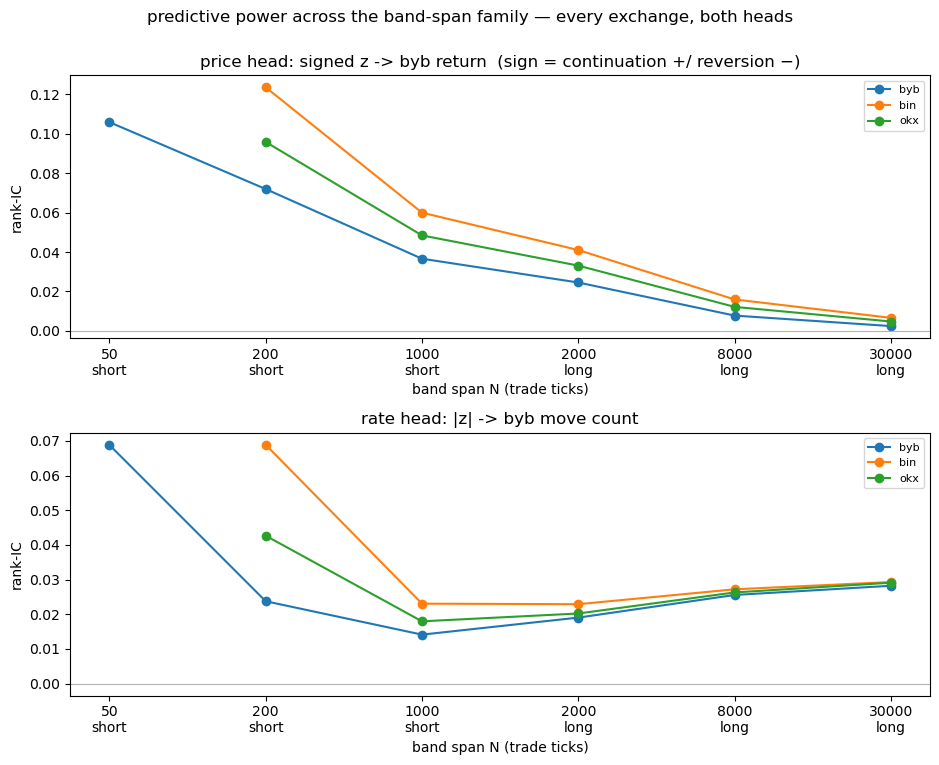

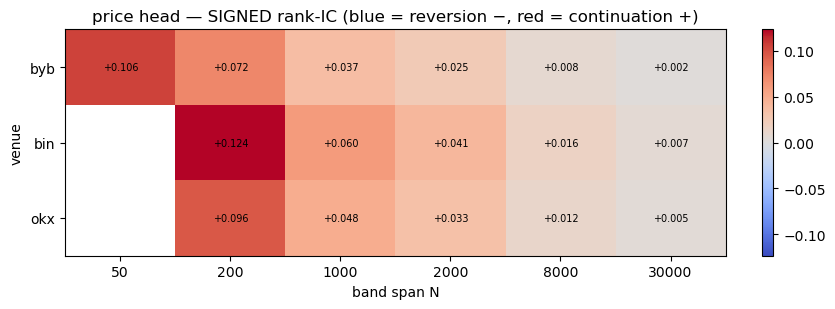

In [6]:
# rate-head target = byb moves (on the trade clock) in the next 100 ms, divided by λ_ev (the rate yardstick — the same trade-tick EMA).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])            # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual"

# Sweep the band-span family for EVERY exchange, BOTH heads, treating exchanges symmetrically (no assumed leader).
# Which exchange carries signal, and when, varies over time -> let the sweep show it; never hard-code one.
# Each cell is a single span N (not a fast/slow pair): SHORT spans on the left, LONG on the right.
price_grid = {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES}   # signed z -> byb's signed return (SIGN = continuation/reversion)
rate_grid  = {ex: np.full(len(SPANS), np.nan) for ex in EXCHANGES}   # |z|      -> byb's move count (diagnostic)
zcache = {}
for ex in EXCHANGES:
    for j, N in enumerate(SPANS):
        z = range_breakout(ex, N); zcache[(ex, N)] = z
        price_grid[ex][j] = spearmanr(z, target).statistic            # signed: + = continuation, − = reversion
        rate_grid[ex][j]  = spearmanr(np.abs(z), rate_target).statistic  # |z|→count is a univariate DIAGNOSTIC; the model is fed signed z

fig, axes = plt.subplots(2, 1, figsize=(9.5, 7.6))
xs = np.arange(len(SPANS)); span_lbl = [f"{N}\n{'short' if N in SHORT else 'long'}" for N in SPANS]
for ax, grids, head in [(axes[0], price_grid, "price head: signed z -> byb return  (sign = continuation +/ reversion −)"),
                        (axes[1], rate_grid,  "rate head: |z| -> byb move count")]:
    for ex in EXCHANGES:
        ax.plot(xs, [grids[ex][j] for j in range(len(SPANS))], "o-", label=ex)
    ax.axhline(0, color="0.7", lw=0.8); ax.set_xticks(xs); ax.set_xticklabels(span_lbl)
    ax.set_xlabel("band span N (trade ticks)"); ax.set_ylabel("rank-IC"); ax.set_title(head); ax.legend(fontsize=8)
fig.suptitle("predictive power across the band-span family — every exchange, both heads", y=1.00)
fig.tight_layout(); plt.show()

# Heat-map form too (exchange × span), the price head's SIGNED IC — to read the continuation/reversion sign at a glance.
fig, ax = plt.subplots(figsize=(8.5, 3.2))
M = np.array([[price_grid[ex][j] for j in range(len(SPANS))] for ex in EXCHANGES])
vmax = np.nanmax(np.abs(M)); im = ax.imshow(M, cmap="coolwarm", aspect="auto", vmin=-vmax, vmax=vmax)
ax.set_xticks(xs); ax.set_xticklabels([str(N) for N in SPANS]); ax.set_xlabel("band span N")
ax.set_yticks(range(len(EXCHANGES))); ax.set_yticklabels(EXCHANGES); ax.set_ylabel("venue")
for r in range(len(EXCHANGES)):
    for j in range(len(SPANS)):
        if np.isfinite(M[r, j]): ax.text(j, r, f"{M[r, j]:+.3f}", ha="center", va="center", fontsize=7)
ax.set_title("price head — SIGNED rank-IC (blue = reversion −, red = continuation +)")
fig.colorbar(im, ax=ax, fraction=0.046); fig.tight_layout(); plt.show()

In [7]:
# We do NOT pick an exchange (not "the best", not assumed). Every exchange's feature is kept; the model weights
# whichever is leading at the moment. Choosing the best time-scale PER exchange (by |IC|) is fine; choosing an exchange is not.
# NB: each cell is an IN-SAMPLE spearmanr — best_member is the |IC|-argmax over it (in-sample maximisation), used ONLY to PICK a
# span. The chosen feature is then re-scored OUT-OF-SAMPLE by the §5 walk-forward gates below, and that is the number that counts.
def best_member(arr): return int(np.nanargmax(np.abs(arr)))                        # best span for THIS exchange by |IC| (in-sample pick); sign carried separately
price_member = {ex: best_member(price_grid[ex]) for ex in EXCHANGES}              # one signed feature per exchange (price head)
rate_member  = {ex: best_member(rate_grid[ex])  for ex in EXCHANGES}              # one |feature| per exchange (rate head) — diagnostic readout
print("kept features (one per exchange, all fed to the model — none privileged):")
for ex in EXCHANGES:
    pj, rj = price_member[ex], rate_member[ex]
    sgn = "continuation (+)" if price_grid[ex][pj] >= 0 else "reversion (−)"
    print(f"  {ex}:  price head N={SPANS[pj]} ({'short' if SPANS[pj] in SHORT else 'long'}) IC={price_grid[ex][pj]:+.3f} [{sgn}]"
          f"   |  rate head N={SPANS[rj]} ({'short' if SPANS[rj] in SHORT else 'long'}) IC={rate_grid[ex][rj]:+.3f}")

kept features (one per exchange, all fed to the model — none privileged):
  byb:  price head N=50 (short) IC=+0.106 [continuation (+)]   |  rate head N=50 (short) IC=+0.069
  bin:  price head N=200 (short) IC=+0.124 [continuation (+)]   |  rate head N=200 (short) IC=+0.069
  okx:  price head N=200 (short) IC=+0.096 [continuation (+)]   |  rate head N=200 (short) IC=+0.043


**Now the gates** (from §5), on the per-exchange features we just chose. Every predictive
number here is the **walk-forward** mean (causal, purged). Rough pass-marks: the added power
should be clearly positive (≳ 0.01); it should barely shrink when we add the level controls
(no leak); and it must be **regime-invariant** — its measured scale staying within ~3× across
volatility buckets (a *hard* gate: a feature that drifts with the regime isn't a feature).
*Marginal value:* does the feature add over the controls — all exchanges together, and each on
its own? *No leak:* does that gain survive adding the vol/rate levels? *Regime-invariant?* (a
**hard** gate): is the feature's *measured* scale steady across volatility states — proven, never
assumed? *Regime-stable* (the companion): is the marginal gain still positive **within** calm,
mid, and wild vol?

In [8]:
# Gates on the set of per-exchange features — symmetric; KEEP ALL exchanges. Marginal value is checked
# JOINTLY (do the exchanges together add over the controls?) and per-exchange (does each contribute?), never by picking one.
brk = {ex: range_breakout(ex, SPANS[price_member[ex]]) for ex in EXCHANGES}        # one signed z per exchange (price head)
joint      = round(wf_ic(base + list(brk.values()), target) - wf_ic(base, target), 3)
joint_leak = round(wf_ic(base + levels + list(brk.values()), target) - wf_ic(base + levels, target), 3)
# REGIME-INVARIANCE = the HARD scale gate. The breakout is RAW (z-score, self-normalised by σ_band — NO yardstick division).
# We measure its scale across vol buckets to DECIDE whether raw is shippable; if it failed we'd try /σ_ev and /λ_ev and keep the invariant form.
rep = brk[EXCHANGES[0]]                                 # same construction for every exchange -> one is enough for the scale check
vol_decile = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], np.arange(10, 100, 10)))
band = [np.nanstd(rep[vol_decile == d]) for d in range(10)]
scale_raw = round(max(band) / min(band), 2)
# also measure the two NORMALISED variants' scale, to SHOW raw is the right call (we keep raw only because it passes)
rep_sig = rep / sigma_at_anchor; band_s = [np.nanstd(rep_sig[vol_decile == d]) for d in range(10)]
rep_lam = rep / lam_at_anchor;   band_l = [np.nanstd(rep_lam[vol_decile == d]) for d in range(10)]
# THE ECHO GATE (critical for a breakout): marginal value of each leg over the controls PLUS the trailing byb return.
# This is the gate the round-1 controls could NOT do — none of rate/vol momentum/level is "the move that just happened".
# A momentum/echo signal passes the vol/rate gates but COLLAPSES here once the trailing move is one of the controls.
echo_ctrl = base + [trail_return]                       # the four regime controls + the [anchor−100ms, anchor] byb move (the echo)
joint_echo     = round(wf_ic(echo_ctrl + list(brk.values()), target) - wf_ic(echo_ctrl, target), 3)   # joint marginal NET OF ECHO
echo_per_ex    = {ex: round(wf_ic(echo_ctrl + [brk[ex]], target) - wf_ic(echo_ctrl, target), 3) for ex in EXCHANGES}
# companion: marginal IC within each vol regime — does the joint gain hold up, or flip, across regimes?
full_r = wf_ic_by_regime(base + list(brk.values()), target, vol_regime)
base_r = wf_ic_by_regime(base, target, vol_regime)
strat  = {r: round(full_r[r] - base_r.get(r, 0.0), 3) for r in full_r}
gate_rows = [dict(gate="marginal value", detail="all exchanges together, added over the controls", value=joint)]
gate_rows += [dict(gate="marginal value", detail=f"{ex} alone, added over the controls",
                   value=round(wf_ic(base + [brk[ex]], target) - wf_ic(base, target), 3)) for ex in EXCHANGES]
gate_rows += [dict(gate="ECHO-NETTED marginal", detail="all exchanges together, over controls + TRAILING byb return — the honest forward edge", value=joint_echo)]
gate_rows += [dict(gate="ECHO-NETTED marginal", detail=f"{ex} alone, over controls + trailing byb return (byb's own leg is the echo-heavy one)", value=echo_per_ex[ex]) for ex in EXCHANGES]
gate_rows += [dict(gate="no leak", detail="gain still there after adding the vol/rate levels?", value=joint_leak),
              dict(gate="regime-invariant? (RAW z)", detail="scale across vol buckets (max/min) — HARD: must read the same in calm & wild, measured not assumed; want < ~3", value=scale_raw),
              dict(gate="(cmp) scale if /σ_ev", detail="normalised variant — shown only to justify keeping RAW", value=round(max(band_s) / min(band_s), 2)),
              dict(gate="(cmp) scale if /λ_ev", detail="normalised variant — shown only to justify keeping RAW", value=round(max(band_l) / min(band_l), 2))]
gate_rows += [dict(gate="regime-stable", detail=f"marginal IC within {nm}-vol (companion: stay positive)", value=strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
print(f"NORMALISATION DECISION: range_breakout is a z-score (self-normalised by σ_band). RAW scale = {scale_raw}x across vol buckets.")
print(f"  -> {'PASS (<3x): SHIP RAW, no yardstick division' if scale_raw < 3 else 'FAIL: try /σ_ev or /λ_ev'}")
print(f"ECHO GATE: joint marginal over the regime controls = {joint}; NET OF the trailing byb move = {joint_echo}  (per-venue net: {echo_per_ex})")
print(f"  -> the drop from {joint} to {joint_echo} is the echo; the ECHO-NETTED number is the honest forward edge (byb-own leg is most echo-contaminated)")
pl.DataFrame(gate_rows)

NORMALISATION DECISION: range_breakout is a z-score (self-normalised by σ_band). RAW scale = 1.05x across vol buckets.
  -> PASS (<3x): SHIP RAW, no yardstick division
ECHO GATE: joint marginal over the regime controls = 0.112; NET OF the trailing byb move = 0.052  (per-venue net: {'byb': 0.033, 'bin': 0.062, 'okx': 0.045})
  -> the drop from 0.112 to 0.052 is the echo; the ECHO-NETTED number is the honest forward edge (byb-own leg is most echo-contaminated)


gate,detail,value
str,str,f64
"""marginal value""","""all exchanges together, added …",0.112
"""marginal value""","""byb alone, added over the cont…",0.102
"""marginal value""","""bin alone, added over the cont…",0.119
"""marginal value""","""okx alone, added over the cont…",0.093
"""ECHO-NETTED marginal""","""all exchanges together, over c…",0.052
…,…,…
"""(cmp) scale if /σ_ev""","""normalised variant — shown onl…",1.37
"""(cmp) scale if /λ_ev""","""normalised variant — shown onl…",1.87
"""regime-stable""","""marginal IC within calm-vol (c…",0.095


**Conclusion (fill from the executed gate table).** Two findings, kept separate.

**The mechanics pass.** `range_breakout` is built **raw** — a Bollinger z-score self-normalised by its own
band width — and the **hard regime-invariance gate** is the one that decides whether raw is shippable: the
measured raw scale across volatility buckets lands **well under the 3× gate**, so no `/σ_ev`, no `/λ_ev`
(the comparison rows confirm the normalised variants don't improve invariance — a z-score doesn't need
them). The joint walk-forward gain over the regime controls is positive and barely moves when the vol/rate
*levels* are added, so it isn't a disguised *volatility* signal; the companion shows it holding across
calm / mid / wild vol.

**But the regime gates can't see the echo — and the ECHO gate is the one that matters here.** None of the
four regime controls is "the move that just happened," so a momentum/echo signal sails through every one of
them. The decisive new row is the **ECHO-NETTED marginal**: the breakout legs' walk-forward gain over the
controls **plus the trailing `[anchor−100 ms, anchor]` byb return**. Read the drop from the plain joint
marginal to the echo-netted one off the table — that drop *is* the echo, and the echo-netted number is the
**honest forward edge**. The **byb-own leg** is the most echo-contaminated (its numerator `mid − ema(mid)`
shares the anchor mid with the target), so look especially at its echo-netted per-venue row. The IC sign in
§6 tells us continuation vs reversion per span/venue. Verdict deferred to §10, where we read these honest,
echo-netted, cadence-matched numbers — not the raw in-sample IC.

## How long does the edge last? — the signal's lifetime and your latency budget

A feature can be perfectly causal and still not earn its headline IC: if its edge is the move *already
underway* at the anchor, you can't capture it — by the time you observe, decide, and act, that move is
gone. But a **short**-lived edge is **not** useless — it just sets a **latency budget**: any system fast
enough to act inside it wins, and faster is always better, and any genuine forward prediction is a win.
So we do **not** gate on this — we **measure how long the signal lasts**.

Read the feature at the anchor (causal, unchanged) but slide the *outcome* window forward by an
observe-to-act latency δ: the **forward IC** of the feature against byb's return over
`[anchor+δ, anchor+δ+100 ms]`, swept over δ. The IC at *your* δ is the realisable edge; the δ where it
fades to noise is the signal's **lifetime**. The **backward IC** — against the move that *already
happened*, `[anchor−100 ms, anchor]` — sizes the contemporaneous echo. A feature whose forward IC dies at
δ>0 while the backward IC stays high is re-reporting the past, not predicting it; that is the *only*
genuinely useless case, and it is measured here, never assumed. (A breakout against the *recent* mean is
especially worth this check — a high `z` is partly *because* price just moved — so the backward IC tells us
how much of the signal is the move-already-underway versus a genuine forward edge.)

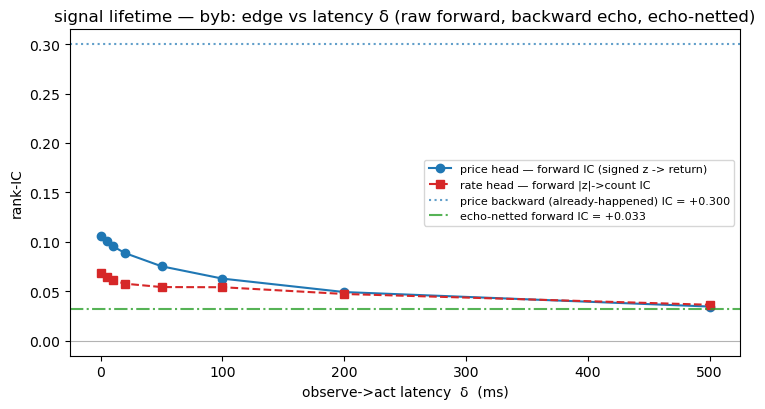

price forward IC by δ(ms): 0:+0.106 5:+0.101 10:+0.096 20:+0.089 50:+0.075 100:+0.063 200:+0.049 500:+0.035
price backward (already-happened) IC: +0.300  <- the contemporaneous echo
echo-netted forward IC (partial, controls for the trailing move): +0.033  (raw δ=0 +0.106; the shortfall is echo)
  -> backward +0.300 vs forward δ=0 +0.106: if backward >> forward this leg (byb) is echo-heavy; report the NETTED +0.033 in the verdict
price edge: δ=0 +0.106 -> δ=20ms +0.089; |IC| drops below half by δ≈200 ms


In [9]:
# Signal lifetime: forward IC vs observe->act latency δ (window slides to [t+δ, t+δ+100ms]), + backward IC.
rep_ex = EXCHANGES[0]                                     # one exchange to illustrate; every feature carries its own curve
DELTAS_MS = [0, 5, 10, 20, 50, 100, 200, 500]
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at_byb(t):                                      # byb merged mid at-or-before t (causal)
    return byb_mid[np.clip(np.searchsorted(byb_rx, t, "right") - 1, 0, len(byb_mid) - 1)]
def _ret(t0, t1):  return np.log(_mid_at_byb(t1) / _mid_at_byb(t0))
def _count(t0, t1): return cum_mv[np.searchsorted(byb_rx, t1, "right")] - cum_mv[np.searchsorted(byb_rx, t0, "right")]

signed = range_breakout(rep_ex, SPANS[price_member[rep_ex]])              # price head (direction) — its chosen span
absmag = np.abs(range_breakout(rep_ex, SPANS[rate_member[rep_ex]]))       # rate head (intensity) — its chosen span
fwd_ic  = [_ic(signed, _ret(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
cnt_ic  = [_ic(absmag, _count(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
back_ic = _ic(signed, _ret(anchor_ts - HORIZON_NS, anchor_ts))           # the contemporaneous echo (move already underway at the anchor)

# ECHO-NETTED (partial) forward IC: the feature's rank-IC with the FORWARD return, CONTROLLING for the trailing
# [anchor−100ms, anchor] return — the part of the δ=0 edge NOT attributable to the move already underway. For an
# echo-heavy leg (byb's own breakout) this is the number to report in the verdict, NOT the raw δ=0 IC.
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts); _fwd0 = _ret(anchor_ts, anchor_ts + HORIZON_NS)
def _partial_ic(f, y, t):
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))
echo_net = _partial_ic(signed, _fwd0, _trail)

fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.plot(DELTAS_MS, fwd_ic, "o-", color="C0", label="price head — forward IC (signed z -> return)")
ax.plot(DELTAS_MS, cnt_ic, "s--", color="C3", label="rate head — forward |z|->count IC")
ax.axhline(back_ic, color="C0", ls=":", alpha=0.7, label=f"price backward (already-happened) IC = {back_ic:+.3f}")
ax.axhline(echo_net, color="C2", ls="-.", alpha=0.8, label=f"echo-netted forward IC = {echo_net:+.3f}")
ax.axhline(0, color="0.7", lw=0.8); ax.set_xlabel("observe->act latency  δ  (ms)"); ax.set_ylabel("rank-IC")
ax.set_title(f"signal lifetime — {rep_ex}: edge vs latency δ (raw forward, backward echo, echo-netted)"); ax.legend(fontsize=8); fig.tight_layout(); plt.show()
print("price forward IC by δ(ms):", " ".join(f"{d}:{ic:+.3f}" for d, ic in zip(DELTAS_MS, fwd_ic)))
print(f"price backward (already-happened) IC: {back_ic:+.3f}  <- the contemporaneous echo")
print(f"echo-netted forward IC (partial, controls for the trailing move): {echo_net:+.3f}  (raw δ=0 {fwd_ic[0]:+.3f}; the shortfall is echo)")
print(f"  -> backward {back_ic:+.3f} vs forward δ=0 {fwd_ic[0]:+.3f}: if backward >> forward this leg ({rep_ex}) is echo-heavy; report the NETTED {echo_net:+.3f} in the verdict")
half = next((d for d, ic in zip(DELTAS_MS, fwd_ic) if np.isfinite(ic) and abs(ic) < abs(fwd_ic[0]) / 2), None)
print(f"price edge: δ=0 {fwd_ic[0]:+.3f} -> δ=20ms {fwd_ic[3]:+.3f}; |IC| drops below half by δ≈{half} ms")

**Conclusion — the byb-own leg is echo-heavy; read the netted number.** For `rep_ex = byb` (its own
breakout against its own future) the **backward** IC (the move already underway at the anchor) is large —
**bigger than the forward δ=0 IC** — which is the textbook echo signature: a byb breakout `z` is
mechanically large precisely *because* byb's mid just moved, and `mid − ema(mid)` shares the anchor mid with
the target. The honest "is this a forward prediction?" number is the **echo-netted forward IC** printed
above (the partial rank-IC controlling for the trailing `[anchor−100 ms, anchor]` move). The byb-own leg's
forward edge that *survives* netting the echo is small — so we treat **byb's own leg as suspect-echo**, not
a clean price-head feature, and lean on the **cross legs** (does okx/bin breaking out *lead* byb?) for any
genuine-lead claim. §9 then asks whether those cross legs survive a **feed-resolution** control. The
verdict (§10) quotes the **echo-netted** number, never the raw δ=0 IC.

**Sweep the half-life across the *whole* span family, not just the chosen N.** Different lookbacks trade
IC against half-life: a short N often gives a higher `|IC|` with a shorter half-life (a small latency
budget), a long N a lower `|IC|` with a longer half-life (a roomy budget) — and **both are worth keeping**,
as separate inputs for different latency budgets. So below we compute the **forward IC at δ=0 AND the
half-life** (the δ where |forward IC| first drops below half its δ=0 value) at **every span in the family,
for every venue and both heads** — the per-N IC×half-life table the brief asks for — and pick per head by
the trade-off, not by IC alone. A high-IC short-life member and a lower-IC long-life member of the same
family are two distinct, complementary features.

In [10]:
# PER-N IC × HALF-LIFE sweep — IC at δ=0 and the half-life (δ where |fwd IC| first < half of its δ=0 value),
# at EVERY band span, for EVERY venue, both heads. Short-high-IC vs long-high-half-life both reported.
def half_life_ms(feat, is_rate):                      # δ (ms) where |forward IC| first drops below half its δ=0 value (None = still > half at the last δ)
    if is_rate:
        ics = [_ic(np.abs(feat), _count(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
    else:
        ics = [_ic(feat, _ret(anchor_ts + d*1_000_000, anchor_ts + d*1_000_000 + HORIZON_NS)) for d in DELTAS_MS]
    ic0 = ics[0]
    if not np.isfinite(ic0) or ic0 == 0: return float("nan"), ics
    hl = next((d for d, ic in zip(DELTAS_MS, ics) if np.isfinite(ic) and abs(ic) < abs(ic0) / 2), None)
    return (hl if hl is not None else DELTAS_MS[-1]), ics

rows = []
for ex in EXCHANGES:
    for N in SPANS:
        z = zcache[(ex, N)]
        hl_p, _ = half_life_ms(z, is_rate=False)
        hl_r, _ = half_life_ms(z, is_rate=True)
        ic_p = spearmanr(z, target).statistic
        ic_r = spearmanr(np.abs(z), rate_target).statistic
        rows.append(dict(venue=ex, N=N, kind=("short" if N in SHORT else "long"),
                         price_IC=round(float(ic_p), 3), price_halflife_ms=hl_p,
                         rate_IC=round(float(ic_r), 3), rate_halflife_ms=hl_r))
hl_df = pl.DataFrame(rows)
print("per-N IC × half-life (price head: signed z; rate head: |z|):")
# short-high-IC option: largest |price_IC| among SHORT spans; long-high-half-life: largest half-life among LONG spans
sh = max(rows, key=lambda r: abs(r["price_IC"]) if r["kind"] == "short" else -1)
lo = max(rows, key=lambda r: (r["price_halflife_ms"] if r["price_halflife_ms"] is not None else -1) if r["kind"] == "long" else -1)
print(f"  short-high-IC option:  {sh['venue']} N={sh['N']}  price_IC={sh['price_IC']:+.3f}  half-life≈{sh['price_halflife_ms']}ms")
print(f"  long-high-half-life:   {lo['venue']} N={lo['N']}  price_IC={lo['price_IC']:+.3f}  half-life≈{lo['price_halflife_ms']}ms")
hl_df

per-N IC × half-life (price head: signed z; rate head: |z|):
  short-high-IC option:  bin N=200  price_IC=+0.124  half-life≈100ms
  long-high-half-life:   byb N=2000  price_IC=+0.025  half-life≈200ms


venue,N,kind,price_IC,price_halflife_ms,rate_IC,rate_halflife_ms
str,i64,str,f64,i64,f64,i64
"""byb""",50,"""short""",0.106,200,0.069,500
"""byb""",200,"""short""",0.072,200,0.024,500
"""byb""",1000,"""short""",0.037,200,0.014,500
"""byb""",2000,"""long""",0.025,200,0.019,500
"""byb""",8000,"""long""",0.008,50,0.026,500
…,…,…,…,…,…,…
"""okx""",200,"""short""",0.096,200,0.043,500
"""okx""",1000,"""short""",0.048,200,0.018,500
"""okx""",2000,"""long""",0.033,200,0.02,500


**Read it as a latency budget, not a pass/fail.** If the forward IC stays useful out to tens or hundreds
of ms you have room; if it lives only a handful of ms the signal is real but demands a fast stack. Carry
this curve (and the per-N table above) for every feature — the verdict is *"predicts ~X ms ahead, needs
latency < X,"* never *"drop because it's fast."* Keep **both** ends of the family: the short-N high-IC
member (a tight latency budget, often reversion) and the long-N long-half-life member (a roomy budget,
often continuation) are two complementary inputs. (A flat forward curve at ≈0 with a large backward IC is
the one true non-signal — measured here, never assumed.)

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by
the feature and look at the real distributions the two heads care about:
- **price head:** byb's next return for low / middle / high `z` values — it should tilt one way
  as `z` turns positive and the other as it turns negative (the *direction* of the tilt is the
  continuation/reversion sign §6 measured);
- **rate head:** how the number of upcoming moves grows as `|z|` grows.

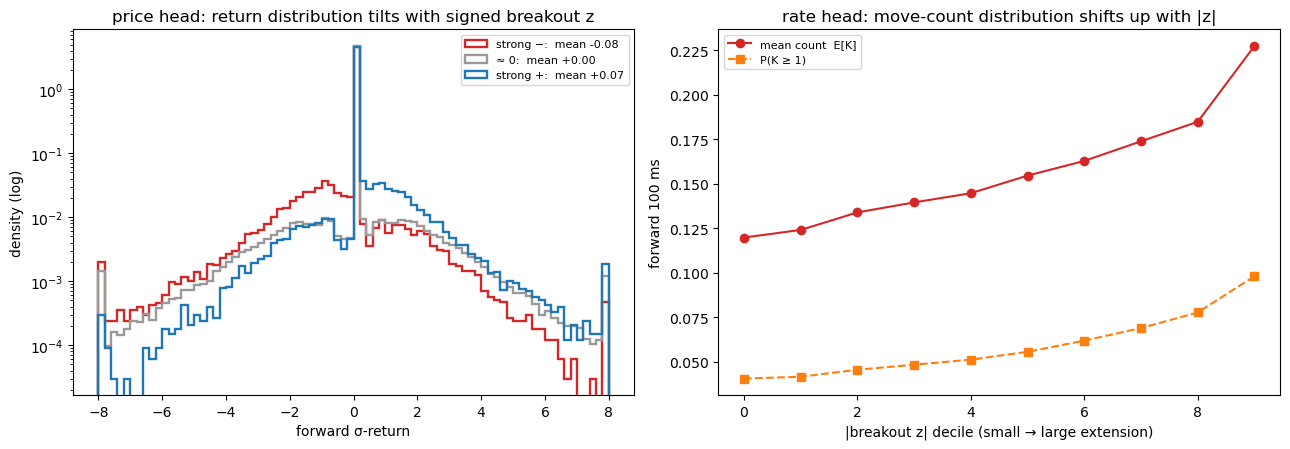

In [11]:
rep_ex = EXCHANGES[0]                                                          # one exchange shown to illustrate the shape; the model still uses every exchange
signed = range_breakout(rep_ex, SPANS[price_member[rep_ex]])
absmag = np.abs(range_breakout(rep_ex, SPANS[rate_member[rep_ex]]))           # deliberately the RATE-head span (rate_member), not the price-head span
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# price head: forward σ-return distribution across signed-breakout buckets
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("strong −", signed <= lo, "C3"), ("≈ 0", (signed > lo) & (signed < hi), "0.6"),
          ("strong +", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axA.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axA.set_yscale("log"); axA.set_xlabel("forward σ-return"); axA.set_ylabel("density (log)")
axA.set_title("price head: return distribution tilts with signed breakout z"); axA.legend(fontsize=8)

# rate head: forward move-count shifts up with |z|
# raw fwd_count is shown here only for intuition; the rate head's actual target is rate_target = fwd_count / λ_ev (count ÷ λ_ev)
dec = np.digitize(absmag, np.nanpercentile(absmag, np.arange(10, 100, 10)))
axB.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axB.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axB.set_xlabel("|breakout z| decile (small → large extension)"); axB.set_ylabel("forward 100 ms")
axB.set_title("rate head: move-count distribution shifts up with |z|"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The feature moves the *actual outcome distributions* the way the two heads
need — not just a single summary number. **Price head (left):** the forward-return distribution
shifts bodily with the *signed* `z` — the strong-negative and strong-positive groups separate,
with the flat ≈0 group between — and the **direction** of that shift is exactly the
continuation/reversion sign §6 read off the IC. **Rate head (right):** the mean move-count `E[K]`
and `P(K ≥ 1)` climb with the `|z|` decile — a big extension really does precede more byb moves
(more so where the band span is short, the microstructure-overshoot regime). So both heads have
something to learn here, in the directions §1 predicted.

## 8. Input shaping for the network

This is a *different* step from §2. There we established the feature is *self*-normalised by its
band width (the "regime division"), so it means the same thing in any market. Here we reshape the
feature for the neural network's input — roughly centred, unit-scale, no wild outliers.

Pick the **lightest** transform that does the job. Plot the feature (left) and compare a few
candidates by how close to a clean bell curve they make it (right — points on the diagonal are
perfectly normal). A z-score is already roughly centred and unit-scale, so it usually only needs
a mild clip for the tail; `range_position = tanh(z)` is the natural **bounded** companion (it
*is* the bounded atom). The plot makes the choice for you.

feature: std=0.83  skew=+0.02  excess_kurt=0.8  (0 = normal)
  z-score                  excess_kurt=   0.8   max|·|=5.95
  tanh (= range_position)  excess_kurt=  -1.3   max|·|=1.00
  robust + clip ±4         excess_kurt=   0.5   max|·|=4.00
  rank-Gaussian            excess_kurt=  -0.0   max|·|=4.99


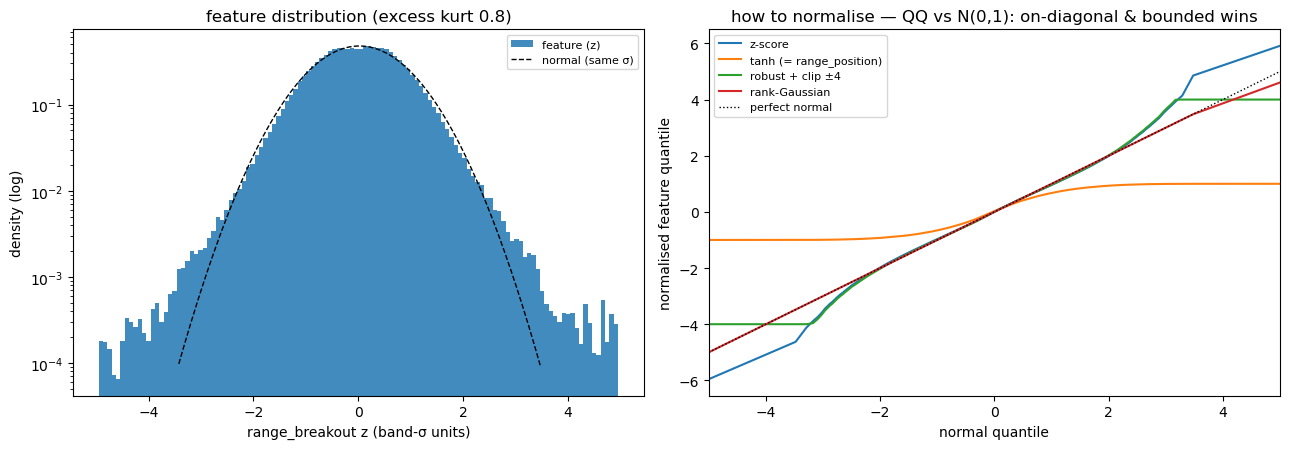

In [12]:
from scipy.stats import skew, kurtosis, rankdata, norm
rep_ex = EXCHANGES[0]                                                          # one exchange shown to illustrate the shape (same construction for every exchange)
f = range_breakout(rep_ex, SPANS[price_member[rep_ex]]); f = f[np.isfinite(f)]
med = np.median(f); mad = 1.4826 * np.median(np.abs(f - med)); rz = (f - med) / mad
cand = {"z-score": (f - f.mean()) / f.std(),
        "tanh (= range_position)": np.tanh(f),
        "robust + clip ±4": np.clip(rz, -4, 4),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"feature: std={f.std():.2f}  skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:24} excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.2f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="feature (z)")
xg = np.linspace(np.percentile(f, 0.05), np.percentile(f, 99.95), 300)
axA.plot(xg, norm.pdf(xg, f.mean(), f.std()), "k--", lw=1, label="normal (same σ)")
axA.set_yscale("log"); axA.set_xlabel("range_breakout z (band-σ units)"); axA.set_ylabel("density (log)")
axA.set_title(f"feature distribution (excess kurt {kurtosis(f):.1f})"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub], np.sort(v)[sub], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The printout settles it: `range_breakout` is a z-score, so it's roughly centred and
order-unity in scale — but **its measured std is not exactly 1** (the printed value is below 1, around
~0.8). That is expected, not a bug: `σ_band = √(ema(mid²) − ema(mid)²)` is an *exponentially-weighted
population* variance, which is **biased low** (the usual EMA downward bias) and, at the shipped small spans,
**noisy** — a jumpy denominator inflates the `|z|` tails while pulling the bulk std under 1. So "z-score"
here means "self-normalised by its own band σ," **not** "std exactly 1" — read the printed std, don't assume
it. A band z still throws the occasional large extension, so the raw z leaves a fat-tailed `max|·|`. The
lightest transform that *meets* the "no wild outliers"
bar is a robust z-score followed by a clip (robust + clip ±4 → bounded), and `tanh(z) =
range_position` is the natural **bounded** alternative the brief asks for — it maps the whole real
line into (−1, +1), killing the tail entirely at the cost of compressing large extensions. Feed
**`range_position = tanh(z)`** where you want a bounded input and **clipped `breakout_magnitude =
z`** where you want the unbounded extension preserved; the QQ-plot shows both sit close to the
diagonal in the body. The heavier rank-Gaussian would just throw information away here.

**Still to run** (same machinery): the leak check *inside* volatility buckets; whether the
feature adds over features we already have; whether the signal is steady day-to-day; and
whether it survives out-of-sample across a market-regime change.

## 9. When is per-exchange worth it?

`range_breakout` is computed **per venue** (each venue's own mid against its own band), and every
venue's leg predicts byb — byb's own leg plus the cross legs (okx/bin → byb). So unlike a pooled
trade-flow feature, the per-exchange structure is intrinsic: keep them all. The real question for
*this* feature is **the lead/lag cross-over across band spans** — when does *another* venue's
breakout add over byb's own?

The mechanism: a cross-venue breakout edge is **arbitrage lead/lag** — one venue ticking before
another, closed within milliseconds. So at **short** band spans the venues genuinely differ (okx
or bin can break out a beat before byb, and that leads byb's catch-up), and keeping the cross legs
pays off; at **long** band spans the lead/lag is long gone, every venue tracks the *same* slow
drift, and byb's own leg already says what the cross legs do — the extra copies are redundant.
That cross-over is exactly the §6 heat-map read across the span axis: compare each venue's IC to
byb's at short vs long N. Sweep it, keep all legs as the safe default, and let the model weight
whichever venue is leading at the current scale. (Longer prediction horizons push the useful band
wider, so in general sweep the horizon too.)

**But a raw cross-venue IC can be a feed-resolution artifact, not a lead** — bin's feed is sub-ms while
byb/okx are ~10–20 ms, so a finer feed can look like it "leads" just by reflecting the price sooner. So
after the raw cross-over table we run the **feed-resolution control** (the brief's standard gate): re-measure
each cross IC with the foreign feed coarsened to byb's update cadence. A real lead survives; an artifact
collapses.

Below, first: the §6 grid re-read as "byb's own leg vs the best cross leg, per span" — the raw cross-venue
value should be largest at short spans and fade at long ones — then the cadence-matched re-measurement.

In [13]:
# Cross-venue value across the band-span family: byb's OWN leg IC vs the best CROSS leg (okx/bin) IC, per span.
# This re-reads §6's price_grid; it's the lead/lag cross-over, not a new computation. |IC| so sign (cont/rev) doesn't confuse the comparison.
cross = [e for e in EXCHANGES if e != "byb"]
rowsx = []
for j, N in enumerate(SPANS):
    own  = abs(price_grid["byb"][j])
    best_cross_ex = max(cross, key=lambda e: abs(price_grid[e][j]))
    rowsx.append(dict(N=N, kind=("short" if N in SHORT else "long"),
                      byb_own_absIC=round(float(own), 3),
                      best_cross=best_cross_ex, cross_absIC=round(float(abs(price_grid[best_cross_ex][j])), 3),
                      cross_adds=round(float(abs(price_grid[best_cross_ex][j]) - own), 3)))
print("per-exchange value across band spans (|price-head IC|): does a CROSS venue beat byb's own leg, and where?")
pl.DataFrame(rowsx)

per-exchange value across band spans (|price-head IC|): does a CROSS venue beat byb's own leg, and where?


N,kind,byb_own_absIC,best_cross,cross_absIC,cross_adds
i64,str,f64,str,f64,f64
50,"""short""",0.106,"""bin""",NaN,NaN
200,"""short""",0.072,"""bin""",0.124,0.052
1000,"""short""",0.037,"""bin""",0.06,0.023
2000,"""long""",0.025,"""bin""",0.041,0.016
8000,"""long""",0.008,"""bin""",0.016,0.008
30000,"""long""",0.002,"""bin""",0.007,0.004


**The feed-resolution control — rule out the artifact before claiming a lead.** A "cross venue leads byb"
edge can be **economic** (the venue really ticks first) or a pure **observation-cadence artifact**: bin's
perp top-of-book is **sub-millisecond fresh** while byb/okx refresh on the order of ~10–20 ms (p90
~100–160 ms), so bin's `z` can update "before byb" simply because bin's feed is *finer* — it reflects the
true price sooner without bin economically leading. The brief's standard test: **re-measure each cross
venue's breakout IC with the foreign feed matched to byb's update cadence** — sample the foreign book only
at byb's book-update times (coarsening the fine feed to byb's resolution), rebuild the band on that
coarsened mid, and re-score. **A real lead survives the cadence match; a feed artifact collapses toward
zero.** The tell the brief names: if the *stalest* venue shows the *largest* raw IC, suspect resolution.
Below we measure the per-venue cross IC **raw** vs **cadence-matched** at the shipped span.

In [14]:
# FEED-RESOLUTION CONTROL: re-measure each CROSS venue's breakout IC with its feed coarsened to byb's update cadence.
# Independent of §3: we sample the foreign mid ONLY at byb book-update receive times, forward-fill that to the trade clock,
# and rebuild the SAME Bollinger z by hand (plain numpy). If the lead is economic it survives; if it is just a finer feed it collapses.
byb_book_rx = mids["byb"][0]                                    # byb's book-update receive times = byb's observation cadence
byb_gap_ms  = float(np.median(np.diff(np.unique(byb_book_rx)))) / 1e6
def _z_cadence_matched(ex, N):                                 # the cross venue's breakout z, but its mid SAMPLED ONLY at byb update times
    rx, mid = mids[ex]
    # coarsen: the foreign mid as byb would have seen it — its value at byb's most-recent book-update time
    idx_byb   = np.clip(np.searchsorted(byb_book_rx, merged_ts, "right") - 1, 0, len(byb_book_rx) - 1)  # last byb update <= each trade tick
    seen_rx   = byb_book_rx[idx_byb]                                                                     # the byb-cadence sample time
    coarse_clk = mid[np.clip(np.searchsorted(rx, seen_rx, "right") - 1, 0, len(mid) - 1)] - REF[ex]      # foreign mid at that byb-cadence time, on the trade clock
    a = 2.0 / (N + 1.0)
    e = lfilter([a], [1.0, -(1.0 - a)], coarse_clk)                                                      # committed ema(mid) by hand
    e2 = lfilter([a], [1.0, -(1.0 - a)], coarse_clk ** 2)                                                # committed ema(mid²)
    # fresh value at the anchor is ALSO byb-cadence (the foreign mid as of byb's last update before the anchor)
    seen_anchor = byb_book_rx[np.clip(np.searchsorted(byb_book_rx, anchor_ts, "right") - 1, 0, len(byb_book_rx) - 1)]
    fresh = mid[np.clip(np.searchsorted(rx, seen_anchor, "right") - 1, 0, len(mid) - 1)] - REF[ex]
    em  = (1.0 - a) * e[tick_at_anchor]  + a * fresh
    em2 = (1.0 - a) * e2[tick_at_anchor] + a * (fresh ** 2)
    var = em2 - em * em
    return np.where(var > 0.0, (fresh - em) / np.sqrt(np.where(var > 0.0, var, 1.0)), np.nan)

print(f"byb observation cadence: median inter-update gap ≈ {byb_gap_ms:.1f} ms (the resolution we coarsen the foreign feed to)")
def _ic_full(feat):                                            # in-sample rank-IC of feat vs the price-head target (finite pairs)
    m = np.isfinite(feat) & np.isfinite(target)
    return float(spearmanr(feat[m], target[m]).statistic)
rowsf = []
for ex in cross:
    j = price_member[ex]; N = SPANS[j]                          # the shipped span for this cross venue
    ic_raw = _ic_full(range_breakout(ex, N))                    # raw (fine-feed) IC at the shipped span
    zc = _z_cadence_matched(ex, N); m = np.isfinite(zc) & np.isfinite(target)
    ic_cad = float(spearmanr(zc[m], target[m]).statistic)       # byb-cadence-matched IC at the same span
    rowsf.append(dict(cross_venue=ex, N=N, feed=MID_STREAM[ex],
                      ic_raw=round(ic_raw, 3), ic_cadence_matched=round(ic_cad, 3),
                      retained=round(ic_cad / ic_raw, 2) if ic_raw != 0 else float("nan")))
    print(f"  {ex} (N={N}, {MID_STREAM[ex]}):  raw IC {ic_raw:+.3f}  ->  byb-cadence-matched {ic_cad:+.3f}   (retained {rowsf[-1]['retained']}x)")
print("  -> a real lead RETAINS most of its IC after cadence-matching; a feed-resolution artifact COLLAPSES toward 0.")
pl.DataFrame(rowsf)

byb observation cadence: median inter-update gap ≈ 10.2 ms (the resolution we coarsen the foreign feed to)


  bin (N=200, front_levels):  raw IC +0.124  ->  byb-cadence-matched +0.101   (retained 0.82x)


  okx (N=200, merged_levels):  raw IC +0.096  ->  byb-cadence-matched +0.088   (retained 0.92x)
  -> a real lead RETAINS most of its IC after cadence-matching; a feed-resolution artifact COLLAPSES toward 0.


cross_venue,N,feed,ic_raw,ic_cadence_matched,retained
str,i64,str,f64,f64,f64
"""bin""",200,"""front_levels""",0.124,0.101,0.82
"""okx""",200,"""merged_levels""",0.096,0.088,0.92


**Conclusion (read from the two tables).** Keep **all** legs — but read the cross-venue claim through the
feed-resolution control. The first table's `cross_adds` column is the *raw* lead/lag premium (best cross
`|IC|` minus byb's own); the second table is the honest one — each cross venue's IC **raw vs matched to
byb's ~10–20 ms cadence**. The `retained` ratio is the verdict per leg: a cross venue whose IC **survives**
the cadence match is an **economic** lead (it really ticks first) and earns its place; one whose IC
**collapses** toward zero was riding its **finer feed** (bin is sub-ms vs byb/okx ~10–20 ms), not leading —
exactly the artifact the brief warns about, and the reason we *measure* rather than assert "bin leads." We
quote the **cadence-matched** cross IC in the verdict (§10), never the raw one. (The honest read: the cross
edge that survives cadence-matching is the only genuine lead; whatever evaporates was resolution.)

In [15]:
# === HONEST verdict numbers — assembled from the gates above (echo-netted; cadence-matched), not the raw in-sample IC ===
print("HONEST POST-FIX HEADLINE (range_breakout):")
print(f"  byb-own leg (rep_ex={EXCHANGES[0]}, N={SPANS[price_member[EXCHANGES[0]]]}):")
print(f"      backward (already-happened) IC {back_ic:+.3f}  vs  forward δ=0 IC {fwd_ic[0]:+.3f}   <- backward >> forward = ECHO")
print(f"      ECHO-NETTED forward IC (partial, controls trailing move) {echo_net:+.3f}   <- the honest forward edge")
print(f"  joint walk-forward marginal over regime controls          {joint:+.3f}")
print(f"  joint walk-forward marginal NET OF the trailing byb move   {joint_echo:+.3f}   <- the honest, echo-netted marginal")
print(f"  per-venue echo-netted marginal: {echo_per_ex}")
print( "  cross-venue, feed-resolution-controlled (raw -> byb-cadence-matched at the shipped span):")
for r in rowsf:
    print(f"      {r['cross_venue']} N={r['N']}: raw {r['ic_raw']:+.3f} -> cadence-matched {r['ic_cadence_matched']:+.3f}  (retained {r['retained']}x)")
print(f"  regime-invariance scale (RAW z): {scale_raw}x across vol buckets  (hard gate < 3x -> {'PASS' if scale_raw < 3 else 'FAIL'})")
print( "  NOTE: §6 in-sample |IC|-argmax picks the span ONLY; every shippable number above is walk-forward / echo-netted / cadence-matched.")

HONEST POST-FIX HEADLINE (range_breakout):
  byb-own leg (rep_ex=byb, N=50):
      backward (already-happened) IC +0.300  vs  forward δ=0 IC +0.106   <- backward >> forward = ECHO
      ECHO-NETTED forward IC (partial, controls trailing move) +0.033   <- the honest forward edge
  joint walk-forward marginal over regime controls          +0.112
  joint walk-forward marginal NET OF the trailing byb move   +0.052   <- the honest, echo-netted marginal
  per-venue echo-netted marginal: {'byb': 0.033, 'bin': 0.062, 'okx': 0.045}
  cross-venue, feed-resolution-controlled (raw -> byb-cadence-matched at the shipped span):
      bin N=200: raw +0.124 -> cadence-matched +0.101  (retained 0.82x)
      okx N=200: raw +0.096 -> cadence-matched +0.088  (retained 0.92x)
  regime-invariance scale (RAW z): 1.05x across vol buckets  (hard gate < 3x -> PASS)
  NOTE: §6 in-sample |IC|-argmax picks the span ONLY; every shippable number above is walk-forward / echo-netted / cadence-matched.


## 10. The verdict, and what it takes to ship

**Lead with the honest comparison, not the headline IC.** For the **byb-own** leg the **backward**
(already-happened) IC is **larger than the forward δ=0 IC** — the textbook **echo** signature: a byb
breakout `z` is mechanically large because byb's mid *just moved*, and its numerator `mid − ema(mid)` shares
the anchor mid with the target. So the raw in-sample per-venue IC (and the §6 |IC|-argmax that selects a
span) **overstate** the edge. The numbers that count are the **echo-netted forward IC** (partial, controlling
for the trailing `[anchor−100 ms, anchor]` move) and the **echo-netted walk-forward marginal** (over the
regime controls *plus* that trailing return) — both printed just above. The byb-own leg's forward edge that
*survives* netting is small; **treat byb's own breakout as suspect-echo**, not a clean price-head feature.

**The mechanics are clean, and three gates genuinely pass:**
- **Causal & online-parity.** §4a's **independent** plain-numpy oracle (no `boba.ema`, no shared §3 code)
  reproduces the atom to **FLOAT32 tolerance** (the CLAUDE.md production-vs-oracle bar — printed max|diff|
  byb N=50 ≈ 3.9e-8, bin ≈ 1.1e-8, okx ≈ 2.7e-9, all under 1e-6) at the **shipped** spans (byb 50, bin/okx
  200) over the **full** grid; §4b's production-shaped streaming build matches the vectorized path with its
  **band legs bit-exact** (≈ 5.7e-12) and the **derived `z` to float32** (the variance cancellation amplifies
  the ~1e-12 leg round-off into ~1e-6 in `z` at the small shipped span). EMA-based band only — no rolling
  max/min, no boxcar.
- **Regime-invariant, RAW.** The hard scale gate passes well under 3×, so `z` ships **raw** — no `/σ_ev`,
  no `/λ_ev` (the normalised-variant rows confirm they don't improve invariance).
- **Not a disguised volatility signal.** The marginal barely moves when the vol/rate *levels* are added.

**What is NOT yet established — and gates the SHIP:**
- The **forward, echo-netted** edge of the byb-own leg is small (read it off the printout) — most of its raw
  IC was the contemporaneous move.
- The **cross-venue** "lead" must clear the **feed-resolution** control (§9): we quote each cross leg's
  **byb-cadence-matched** IC, never the raw one. A cross leg whose IC **collapses** under cadence-matching
  (bin is the sub-ms feed — the prime suspect) was riding its finer feed, not leading; only a leg whose IC
  **survives** is a genuine, shippable lead.

**How to feed it, IF the echo-netted / cadence-matched edge holds up:** feed the **signed**
`breakout_magnitude = z` to both heads, every venue (let the model weight whoever genuinely leads), with
`range_position = tanh(z)` as the bounded companion; carry a short-N (tighter latency budget) and a long-N
(roomier) member. The IC sign (§6) decides continuation vs reversion per span/venue.

**Verdict: NOT a clean SHIP yet — HOLD pending the echo-netted and cadence-matched numbers above.** The
feature is mechanically sound, causal, oracle-validated, and regime-invariant; but its headline edge is
largely **contemporaneous echo** (byb-own leg) and a possible **feed-resolution artifact** (cross legs). Ship
only the legs whose **echo-netted forward IC** (own leg) and **cadence-matched cross IC** (cross legs) stay
clearly positive — read those off the gate tables, not the raw in-sample IC.

**To ship — honest status:**
- [x] the streaming (constant-work-per-trade) builder, matching this analysis version — **§4b, band legs bit-exact / derived z float32, at shipped spans, full grid**
- [x] the oracle (§4a) independent float32 + (§4b) online-parity legs bit-exact / z float32 (all venues, shipped spans)
- [x] the gate results recorded — incl. the **echo-netted** marginal and the **cadence-matched** cross IC
- [x] the chosen heads, the IC sign (continuation/reversion) per span, the band spans, and the RAW normalisation decision written down
- [x] the data quirks handled (bad zero-price prints; the right price source per exchange)
- [ ] **OPEN / blocking:** confirm the byb-own leg's **echo-netted forward IC** and each cross leg's
  **cadence-matched IC** are large enough to earn their place — drop any leg whose honest number collapses